In [1]:
import rdkit.Chem as Chem
import pandas as pd
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import requests
from tqdm import tqdm
import requests
import ast
import collections

# Functions

In [2]:
def get_identifier_from_title(ID):
    parts = ID.split('_')
    if len(parts) > 2:
        return '_'.join(parts[1:-1])
    else:
        return ID

def get_paired_enantiomers_grouped_by_uniprot_id(folder_path):
    all_identifiers_by_group = {}
    for file in os.listdir(folder_path):
        with open(os.path.join(folder_path, file), 'r') as f:
            df = pd.read_csv(f)
            # Base group is from filename
            if '_inconsistent.csv' in file:
                base_group_identifier = file.split('_inconsistent.csv')[0]
            elif '_consistent.csv' in file:
                base_group_identifier = file.split('_consistent.csv')[0]
            else:
                base_group_identifier = file
            for enantiomer_short_hash in df['enantiomer_short_hash'].unique():
                group_df = df[df['enantiomer_short_hash'] == enantiomer_short_hash]
                group_identifier = f"{base_group_identifier}_{enantiomer_short_hash}"

                found_m0 = False
                found_m1 = False
                file_identifiers = set()
                for _, row in group_df.iterrows():
                    interaction_identifier = row['file']
                    basename = os.path.splitext(os.path.basename(interaction_identifier))[0]
                    if 'm0' in basename and not found_m0:
                        parts = basename.split('interaction_')
                        if len(parts) > 1:
                            identifier = parts[1]
                            if identifier:
                                file_identifiers.add(identifier)
                        found_m0 = True
                    if 'm1' in basename and not found_m1:
                        parts = basename.split('interaction_')
                        if len(parts) > 1:
                            identifier = parts[1]
                            if identifier:
                                file_identifiers.add(identifier)
                        found_m1 = True
                    if found_m0 and found_m1:
                        break
                all_identifiers_by_group[group_identifier] = file_identifiers
    return all_identifiers_by_group

def calc_props(mol):
            if mol is None:
                return pd.Series([None, None, None, None])
            mol_no_h = Chem.RemoveHs(mol)
            mw = float(Descriptors.MolWt(mol_no_h))
            h_acceptors = int(Descriptors.NumHAcceptors(mol))
            rot_bonds = int(rdMolDescriptors.CalcNumRotatableBonds(
                mol_no_h, 
                strict=rdMolDescriptors.NumRotatableBondsOptions.StrictLinkages
            ))
            ring_count = int(Descriptors.RingCount(mol_no_h))
            return pd.Series([mw, h_acceptors, rot_bonds, ring_count])

def filter_molecules_df(
    df, 
    mw_min=181, 
    mw_max=777,
    h_acceptors_max=16, 
    rot_bonds_max=20, 
    small_rings_min=1
):
    if not {"mw", "NumHAcceptors", "NumRotatableBonds", "RingCount"}.issubset(df.columns):
        df[["mw", "NumHAcceptors", "NumRotatableBonds", "RingCount"]] = df["mol"].apply(calc_props)

    mask = (
        (df["mw"] > mw_min) &
        (df["mw"] < mw_max) &
        (df["NumHAcceptors"] <= h_acceptors_max) &
        (df["NumRotatableBonds"] <= rot_bonds_max) &
        (df["RingCount"] >= small_rings_min)
    )

    filtered_df = df[mask].copy()
    filtered_out_df = df[~mask].copy()

    print(f"Number of molecules processed: {len(df)}")
    print(f"Number passed all filters: {len(filtered_df)}")
    print(f"Number filtered out: {len(filtered_out_df)}")
    return filtered_df, filtered_out_df

# Data preprocessing

In [3]:
# get the indentifier of the paired enantiomers
filtered_enantiomer_structures = '../Data/chiral_classification_results/Drug_likeness_evaluation/filtered_enantiomer_with_uniprot_UniProtID_updated.sdf'
paired_enantiomers_group = '../Data/Pharmacophore/paired_enantiomers_pocket_based'

In [4]:
dict_consistent_paired_enantiomers = get_paired_enantiomers_grouped_by_uniprot_id(paired_enantiomers_group)
all_items = [item for sublist in dict_consistent_paired_enantiomers.values() for item in sublist]
print(len(all_items))

719


In [5]:
collected_data = []
all_items_set = set(all_items)
suppl = Chem.SDMolSupplier(filtered_enantiomer_structures)
for mol in suppl:
    if mol is None: 
        continue
    identifier = mol.GetProp('_Name')
    uniprot_id = mol.GetProp('UniProt_IDs')
    inchi = mol.GetProp('InChI')
    matched_items = [item for item in all_items if identifier in item]
    if matched_items:
        for matched in matched_items:
            value_without_mlayer = matched.split('_m')[0]
            collected_data.append({
                "uniprot_id": uniprot_id,
                "identifier": value_without_mlayer,
                "mol": mol,
                "inchi": inchi
            })
enantiomers_matched = pd.DataFrame(collected_data)
print(len(enantiomers_matched))
display(enantiomers_matched.head(3))

719


,uniprot_id,identifier,mol,inchi
0,Q9H2K2,5owt_F37_A_1203,<rdkit.Chem.rdchem.Mol object at 0x7f4c4aac7ed0>,InChI=1S/C18H14N4O3/c1-18(16(24)21-17(25)22-18...
1,Q9H2K2,4buy_F37_A_2164,<rdkit.Chem.rdchem.Mol object at 0x7f4c4aac7e60>,InChI=1S/C18H14N4O3/c1-18(16(24)21-17(25)22-18...
2,P14902,7e0s_HU6_A_502,<rdkit.Chem.rdchem.Mol object at 0x7f4c4aac7760>,InChI=1S/C14H18BrN3O/c15-10-5-12(11-8-17-18-13...


In [6]:
# DrugBank approved drug data
DrugBank_approved_structures = '../../extract_ligand_from_pbd/maestro_manually_check/DrugBank_approved_structures.sdf'
SDMolSupplier = Chem.SDMolSupplier(DrugBank_approved_structures)
approved_entries = []
for mol in SDMolSupplier:
    if mol is not None:
        drugbank_id = mol.GetProp('DRUGBANK_ID') if mol.HasProp('DRUGBANK_ID') else None
        inchi_string = mol.GetProp('INCHI_IDENTIFIER') if mol.HasProp('INCHI_IDENTIFIER') else None
        drug_groups = mol.GetProp('DRUG_GROUPS') if mol.HasProp('DRUG_GROUPS') else None
        generic_name = mol.GetProp('GENERIC_NAME') if mol.HasProp('GENERIC_NAME') else None
        products = mol.GetProp('PRODUCTS') if mol.HasProp('PRODUCTS') else None
        if drug_groups == 'approved' or drug_groups == 'approved; investigational':
            inchi_molconverted = Chem.inchi.MolToInchi(mol) # inchi converted from molecule
            approved_entries.append({
                "DRUGBANK_ID": drugbank_id,
                "mol": mol,
                "INCHI_IDENTIFIER": inchi_molconverted if inchi_molconverted else inchi_string,
                "DRUG_GROUPS": drug_groups,
                "GENERIC_NAME": generic_name,
                "PRODUCTS": products
            })
approved_dict = {}
for entry in approved_entries:
    key = entry["DRUGBANK_ID"]
    approved_dict[key] = entry

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Metal was disconnected; Proton(s) added/removed

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Proton(s) added/removed

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Proton(s) added/removed

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WARNING: Omitted undefined stereo

[15:32:45] WA

In [7]:
approved_df = pd.DataFrame.from_dict(approved_dict, orient='index')
approved_df.reset_index(drop=True, inplace=True)
display(approved_df.head())

,DRUGBANK_ID,mol,INCHI_IDENTIFIER,DRUG_GROUPS,GENERIC_NAME,PRODUCTS
0,DB00006,<rdkit.Chem.rdchem.Mol object at 0x7f4c4a817df0>,InChI=1S/C98H138N24O33/c1-5-52(4)82(96(153)122...,approved; investigational,Bivalirudin,Angiomax; Angiomax RTU; Angiox; Bivalirudin; B...
1,DB00014,<rdkit.Chem.rdchem.Mol object at 0x7f4c4a817840>,InChI=1S/C59H84N18O14/c1-31(2)22-40(49(82)68-3...,approved; investigational,Goserelin,Zoladex; Zoladex LA
2,DB00027,<rdkit.Chem.rdchem.Mol object at 0x7f4c4a817a70>,InChI=1S/C96H135N19O16/c1-50(2)36-71(105-79(11...,approved; investigational,Gramicidin D,Antibiotic Cream; Antibiotic Cream Plus Pain R...
3,DB00035,<rdkit.Chem.rdchem.Mol object at 0x7f4c4a817e60>,InChI=1S/C46H64N14O12S2/c47-35(62)15-14-29-40(...,approved; investigational,Desmopressin,Apo-desmopressin; Auro-desmopressin; Bipazen; ...
4,DB00050,<rdkit.Chem.rdchem.Mol object at 0x7f4c4a817f40>,InChI=1S/C70H92ClN17O14/c1-39(2)31-52(61(94)82...,approved; investigational,Cetrorelix,Cetrorelix; Cetrorelix Acetate; Cetrorelix ace...


In [8]:
Drugbank_filtered, Drugbank_filtered_out = filter_molecules_df(approved_df) # Filter small molecules in DrugBank approved drug with the same filters as enantiomers

Number of molecules processed: 1943
Number passed all filters: 1384
Number filtered out: 559


# Chemical space visualization between DrugBank and the dataset

In [9]:
from sklearn.preprocessing import StandardScaler
from rdkit.Chem import AllChem
from matplotlib.patches import Circle, Patch
import umap
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

/home/hzhang/anaconda3/envs/enantiomers_cliff/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def get_morgan2(mol):
    generator = GetMorganGenerator(radius=2, fpSize=2048)
    fp = generator.GetFingerprint(mol)
    return list(fp.ToBitString())

def plot_umap(np_data_toplot, dataframe):
    colors = {"Approved drugs": "#6a79f7",
            "Enantiomeric ligands": "#ff5b00"}
    markers = {"Approved drugs": "o",
            "Enantiomeric ligands": "x"}  # o: circle, x: cross

    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(np_data_toplot)

    # Define cluster regions
    outlier_indices_1 = np.where((embedding[:, 1] > 8.5) & (embedding[:, 0] < 7))
    outlier_indices_2 = np.where((embedding[:, 1] < 4) & (embedding[:, 1] > 2))
    outlier_indices_3 = np.where((embedding[:, 1] < 2) & (embedding[:, 1] > 0))
    outlier_indices_4 = np.where((embedding[:, 1] > 10.5) & (embedding[:, 0] > 13))

    fig, ax = plt.subplots(figsize=(8, 6))
    for category in colors:
        mask = (dataframe['db'] == category).values
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            c=colors[category], 
            alpha=1,
            label=category,
            s=15,
            marker=markers.get(category)
        )

    circle_patches = []
    cluster_df_dict = {}  # Store dataframe for each cluster
    for idx, (outlier_indices, label, color) in enumerate([
        (outlier_indices_1, "cluster 1", "green"),
        (outlier_indices_2, "cluster 2", "orange"),
        (outlier_indices_3, "cluster 3", "purple"),
        (outlier_indices_4, "cluster 4", "brown"),
    ]):
        if len(outlier_indices[0]) > 0:
            cluster_coords = embedding[outlier_indices]
            center_x, center_y = cluster_coords.mean(axis=0)
            distances = np.linalg.norm(cluster_coords - [center_x, center_y], axis=1)
            radius = distances.max() + 0.1
            circle = Circle((center_x, center_y), radius=radius, edgecolor=color, facecolor='none', lw=1)
            ax.add_patch(circle)
            circle_patches.append(Patch(edgecolor=color, facecolor='none', label=label))
            # Save indices (as integers) and map to dataframe
            cluster_df_dict[label] = dataframe.iloc[outlier_indices]

    handles, labels = ax.get_legend_handles_labels()
    handles += circle_patches
    labels += [patch.get_label() for patch in circle_patches]
    ax.legend(handles=handles, labels=labels, title="Compound group", loc='upper right', fontsize=10)
    ax.set_aspect('equal', 'datalim')
    plt.gca().set_aspect("equal", "datalim")
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 16)
    ax.set_xlabel("UMAP 1", fontsize=15)
    ax.set_ylabel("UMAP 2", fontsize=15)
    plt.tight_layout()
    plt.savefig('umap_plot_ori', dpi=300)
    plt.show()
    return cluster_df_dict

def data_to_visualize_umap(df_1, df_2):
    df_1 = df_1.copy()
    df_2 = df_2.copy()
    df_1['fp'] = df_1.mol.apply(get_morgan2)
    df_2['fp'] = df_2.mol.apply(get_morgan2)
    morgan2_cols_list = ['morgan2_b' + str(i) for i in range(2048)]

    # Make fingerprint DataFrames and remove duplicates separately
    print(f"DrugBank approved drug data before duplicate removal: {len(df_1)}")
    morgan2_df1 = pd.DataFrame(df_1['fp'].to_list(), columns=morgan2_cols_list, index=df_1.index)
    df_1_with_fp = pd.concat([df_1[['db', 'mol']], morgan2_df1], axis=1)
    df_1_with_fp_nodup = df_1_with_fp.drop_duplicates(subset=morgan2_cols_list).reset_index(drop=True)
    print(f"DrugBank approved drug data after duplicate removal: {len(df_1_with_fp_nodup)}")

    print(f"Enantiomeric ligands before duplicate removal: {len(df_2)}")
    morgan2_df2 = pd.DataFrame(df_2['fp'].to_list(), columns=morgan2_cols_list, index=df_2.index)
    df_2_with_fp = pd.concat([df_2[['db', 'mol']], morgan2_df2], axis=1)
    df_2_with_fp_nodup = df_2_with_fp.drop_duplicates(subset=morgan2_cols_list).reset_index(drop=True)
    print(f"Enantiomeric ligands after duplicate removal: {len(df_2_with_fp_nodup)}")

    # Combine both and remove inter-dataset duplicates
    combined_df = pd.concat([df_1_with_fp_nodup, df_2_with_fp_nodup], axis=0, ignore_index=True)
    print(f"Combined data before inter-dataset duplicate removal: {len(combined_df)}")
    combined_df = combined_df.drop_duplicates(subset=morgan2_cols_list).reset_index(drop=True)
    print(f"Combined data after inter-dataset duplicate removal: {len(combined_df)}")

    morgan2_cols = combined_df[morgan2_cols_list].to_numpy()
    result_df = combined_df[['db', 'mol'] + morgan2_cols_list]
    return result_df, morgan2_cols

In [11]:
Drugbank_filtered['db'] = 'Approved drugs'
enantiomers_matched['db'] = 'Enantiomeric ligands'

In [12]:
combined_df, morgan2_cols = data_to_visualize_umap(Drugbank_filtered, enantiomers_matched)

DrugBank approved drug data before duplicate removal: 1384
DrugBank approved drug data after duplicate removal: 1361
Enantiomeric ligands before duplicate removal: 719
Enantiomeric ligands after duplicate removal: 330
Combined data before inter-dataset duplicate removal: 1691
Combined data after inter-dataset duplicate removal: 1677


plot

/home/hzhang/anaconda3/envs/enantiomers_cliff/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hzhang/anaconda3/envs/enantiomers_cliff/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


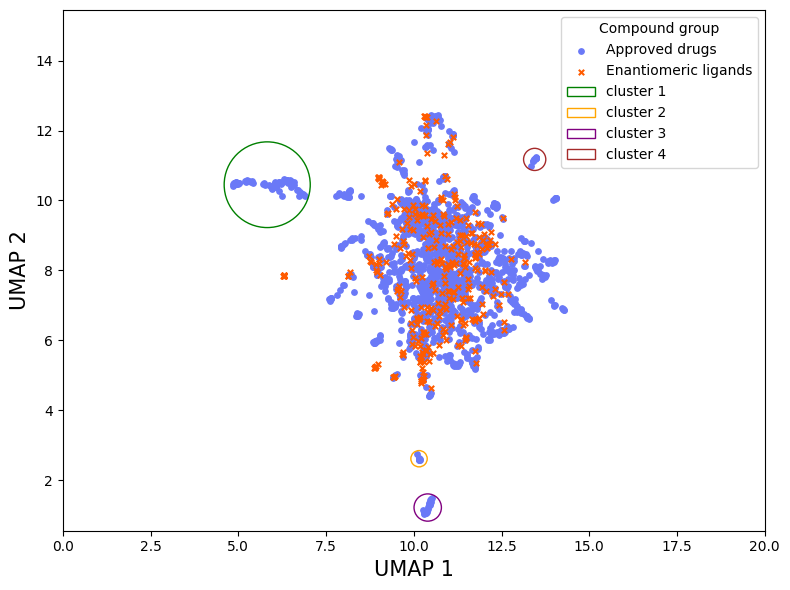

In [13]:
mark_indices=[0,0,3,3,3]
cluster_dict = plot_umap(morgan2_cols,combined_df)

# Protein family distribution of enantiomer pairs

In [14]:
def plot_distribution(series: pd.Series, title: str, xlabel: str, ylabel: str, top_n: int = 20, figsize=(20,10), rotation=45, bar_color="royalblue"):
    value_counts = series.value_counts()
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        x=value_counts.index[:top_n],
        y=value_counts.values[:top_n],
        color=bar_color,
        edgecolor='black'
    )
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel(ylabel, fontsize=13)
    plt.xticks(rotation=rotation, ha='right', fontsize=11)
    plt.yticks(fontsize=12)
    # Add value labels
    for idx, value in enumerate(value_counts.values[:top_n]):
        plt.text(idx, value + max(value_counts.values[:top_n])*0.01, str(value), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

def stringify_entries(cell):
    if isinstance(cell, list):
        return ", ".join(str(x) for x in cell)
    else:
        return cell

load annotated protein family information

In [15]:
df_fam_sim_annotated = pd.read_csv('../Data/df_fam_sim_unknown_by_manual_matching.csv')
display(df_fam_sim_annotated.head(3))
print(df_fam_sim_annotated['protein_family_sim_str'].value_counts())

,inchi_core,uniprot_id,protein_family_sim_str,identifier,pdb_id,note
0,InChI=1S/C18H14N4O3/c1-18(16(24)21-17(25)22-18...,Q9H2K2,ARTD/PARP family,5owt_F37_A_1203,5owt,NaN
1,InChI=1S/C14H18BrN3O/c15-10-5-12(11-8-17-18-13...,P14902,"indoleamine 2,3-dioxygenase family",7e0s_HU6_A_502,7e0s,NaN
2,InChI=1S/C21H30FN5/c1-15-9-19(27-21(23)10-15)1...,P29473,NOS family,3jwz_J14_A_800,3jwz,NaN


protein_family_sim_str
nuclear hormone receptor family              9
dihydrofolate reductase family               6
Tyr protein kinase family                    6
NOS family                                   5
CMGC Ser/Thr protein kinase family           5
                                            ..
glycosyltransferase 41 family                1
tubulin family                               1
purine-cytosine permease (2.A.39) family     1
HDGF family                                  1
glycosyl hydrolase 7 (cellulase C) family    1
Name: count, Length: 162, dtype: int64


In [16]:
## write the full list of protein family information of enantiomers in to file -- may be merged into one final data set and presented as meta data
# counts = df_fam_sim_annotated['protein_family_sim_str'].value_counts()
# fam_table_full = pd.DataFrame({
#     "Family": counts.index,
#     "Count": counts.values
# })
# top_n = 162
# fam_df = fam_table_full.iloc[:top_n].reset_index(drop=True)
# columns = {}
# for i in range(3):
#     columns[f'Family_{i+1}'] = fam_df['Family'][i*54:(i+1)*54].reset_index(drop=True)
#     columns[f'Count_{i+1}'] = fam_df['Count'][i*54:(i+1)*54].reset_index(drop=True)

# fam_18x9 = pd.DataFrame(columns)
# fam_18x9.to_csv('../Data/full_list_protein_family_sim_str_table_18x9.csv', index=False)

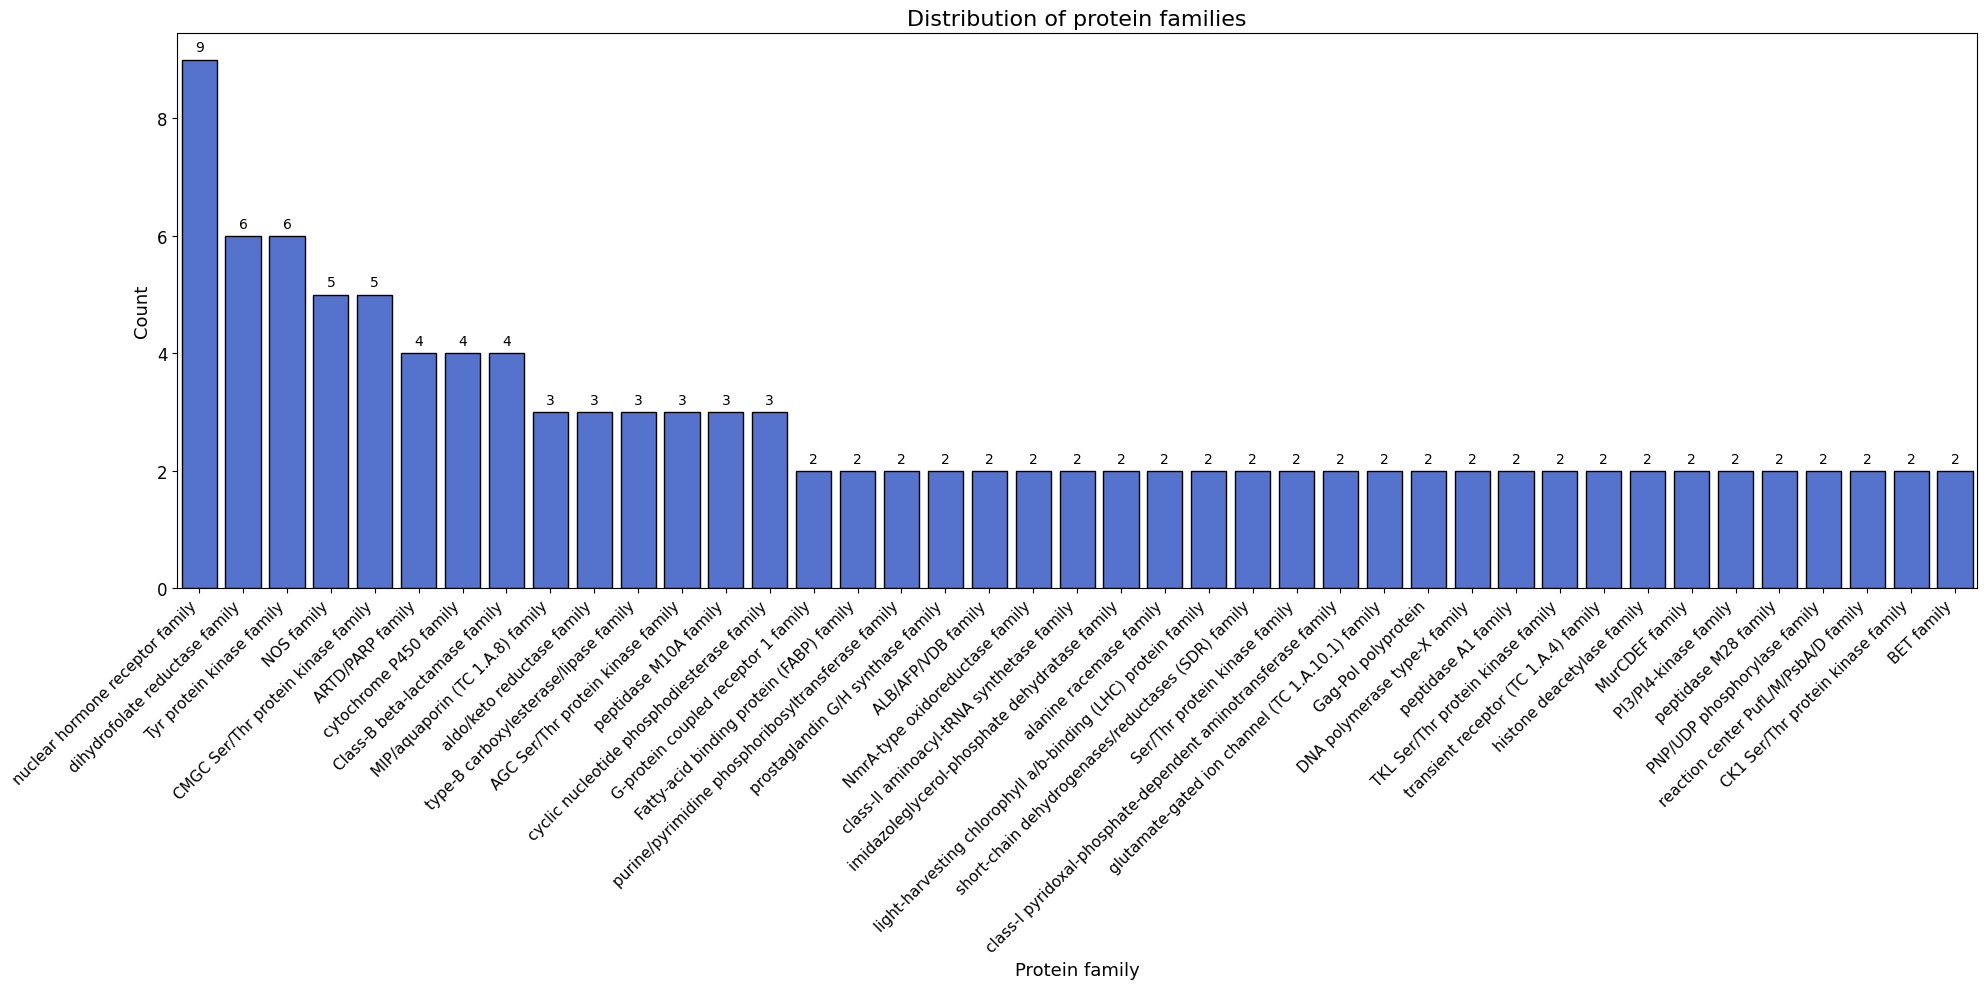

In [17]:
plot_distribution(
    df_fam_sim_annotated['protein_family_sim_str'].apply(stringify_entries),
    title="Distribution of protein families",
    xlabel="Protein family",
    ylabel="Count",
    top_n=41
)

Distribution of the protein family in four curated categories

In [18]:
manual_check_folder = '../Data/Manual_curation'
all_records = []
uniprot_to_family = df_fam_sim_annotated.set_index('uniprot_id')['protein_family_sim_str'].to_dict()

for file in os.listdir(manual_check_folder):
    if file.endswith('.csv') and not 'manualcheck_invalid' in file:
        file_path = os.path.join(manual_check_folder, file)
        df = pd.read_csv(file_path, delimiter='\t')
        df_non4letter_title = df[df['Title'].astype(str).str.len() != 4]
        grouped = df_non4letter_title.groupby('group')
        for group_name, group_df in grouped:
            for idx, row in group_df.iterrows():
                label = row.get('category_manual_check', None)
                ids = row['ID']
                if pd.notna(ids):
                    if isinstance(ids, str) and ids.startswith('[') and ids.endswith(']'):
                        try:
                            ids_list = ast.literal_eval(ids)
                        except Exception:
                            ids_list = []
                    else:
                        ids_list = [ids]
                    for idstr in ids_list:
                        uniprot_id = idstr.split('_')[0]
                        protein_family = uniprot_to_family.get(uniprot_id, None)
                        if protein_family is not None:
                            all_records.append({
                                "group": group_name,
                                "uniprot_id": uniprot_id,
                                "protein_family": protein_family,
                                "manual_label": label
                            })
plot_df = pd.DataFrame(all_records)
plot_df['manual_label'] = plot_df['manual_label'].astype(str)
# Map manual_label as per instructions
manual_label_map = {
    "1.2.1": "1.1",
    "1.2.2": "1.2",
    "1.2.3": "1.3",
    "1.1": "2.0"
}
plot_df['manual_label'] = plot_df['manual_label'].replace(manual_label_map)
print(plot_df['manual_label'].value_counts())
plot_df['group'] = plot_df['group'].astype(str)
display(plot_df.head(3))

manual_label
1.1    645
1.3    439
1.2    427
2       82
Name: count, dtype: int64


,group,uniprot_id,protein_family,manual_label
0,{'g000001_b55a025257'},A0A009KIJ4,type II topoisomerase GyrB family,1.1
1,{'g000001_b55a025257'},A0A009KIJ4,type II topoisomerase GyrB family,1.1
2,{'g000001_b55a025257'},A0A009KIJ4,type II topoisomerase GyrB family,1.1


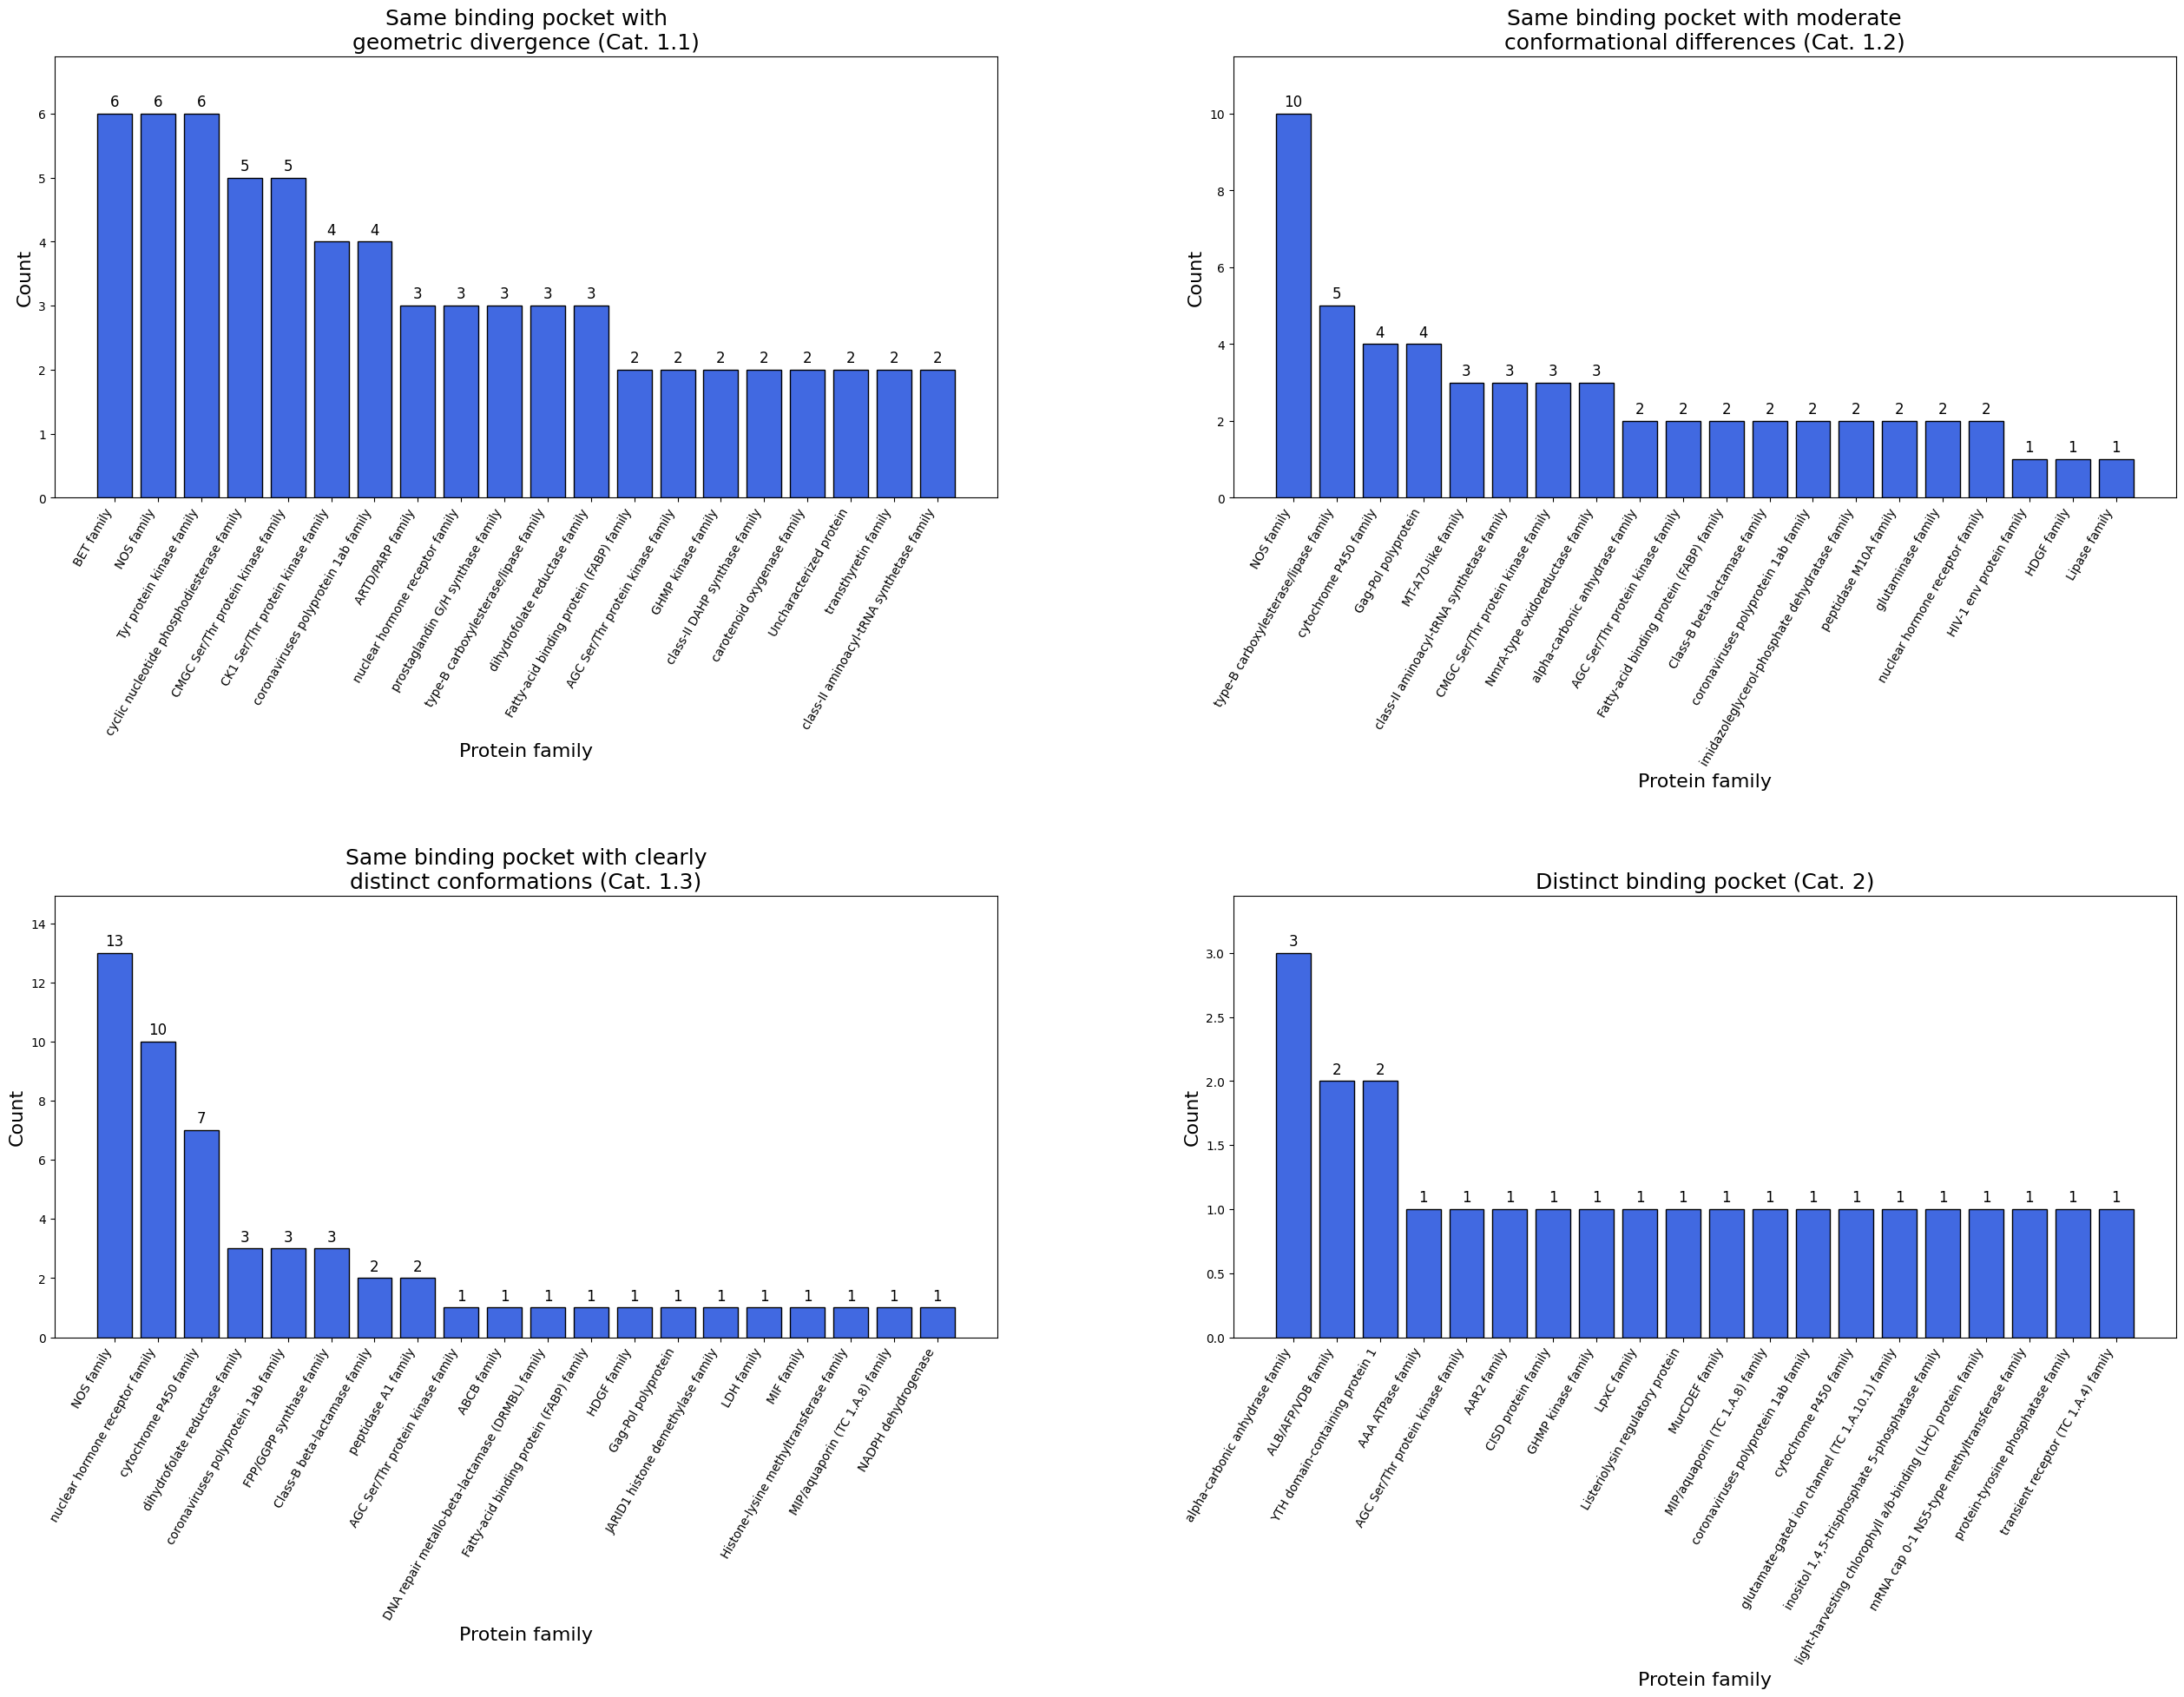

In [19]:
category_label_map = {
    "1.1": "Same binding pocket with\ngeometric divergence (Cat. 1.1)",
    "1.2": "Same binding pocket with moderate\nconformational differences (Cat. 1.2)",
    "1.3": "Same binding pocket with clearly\ndistinct conformations (Cat. 1.3)",
    "2": "Distinct binding pocket (Cat. 2)",
}

codes_in_data = [x for x in plot_df["manual_label"].dropna().unique()]
codes_in_data_sorted = [code for code in ["1.1", "1.2", "1.3", "2"] if code in codes_in_data]
pretty_labels_sorted = [category_label_map.get(code, code) for code in codes_in_data_sorted]

# Adjusted parameters
fig_width = 26
fig_height = 18
title_fontsize = 18
label_fontsize = 16
tick_fontsize = 10
bar_text_fontsize = 12
top_n = 20  # Number to plot per category

if len(codes_in_data_sorted) == 0:
    print("No data to plot for protein family vs. manual label (no categories found).")
else:
    n_rows, n_cols = 2, 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    axes = axes.flatten()
    for ax, code in zip(axes, codes_in_data_sorted):
        df_cat = plot_df[plot_df["manual_label"] == code]
        group_counts = (
            df_cat.groupby("protein_family")["group"]
            .nunique()
            .sort_values(ascending=False)
            .head(top_n)
        )
        x_vals = group_counts.index.tolist()
        y_vals = group_counts.values
        ax.bar(x_vals, y_vals, color="royalblue", edgecolor="black")
        ax.set_title(category_label_map.get(code, code), fontsize=title_fontsize)
        ax.set_xlabel("Protein family", fontsize=label_fontsize)
        ax.set_ylabel("Count", fontsize=label_fontsize)
        ax.set_xticks(range(len(x_vals)))
        ax.set_xticklabels(x_vals, rotation=60, fontsize=tick_fontsize, ha='right')
        ax.set_ylim(0, max(y_vals) * 1.15 if len(y_vals) > 0 else 1)
        for idx2, value in enumerate(y_vals):
            ax.text(
                idx2,
                value + (max(y_vals) * 0.01 if value > 0 else 0.01),
                str(value),
                ha='center',
                va='bottom',
                fontsize=bar_text_fontsize,
            )
        ax.tick_params(axis='y', labelsize=tick_fontsize)
    for j in range(len(codes_in_data_sorted), n_rows * n_cols):
        fig.delaxes(axes[j])
    fig.subplots_adjust(hspace=0.9, wspace=0.25, top=0.94, bottom=0.12, left=0.04, right=0.98)
    plt.show()

# Distribution of three complementary features in the dataset

In [56]:
threshold_training_table = pd.read_csv("../Data/Categorization/threshold_training_table.csv")
print(threshold_training_table.columns)
display(threshold_training_table.head(3))

Index(['info_file', 'pipeline_category', 'manual_label',
       'manual_label_join_method', 'closest_cross_tag_file_a',
       'closest_cross_tag_file_b', 'closest_cross_tag_rmsd_A',
       'closest_cross_tag_similarity', 'category_reason', 'n_m0_structures',
       'n_m1_structures', 'similarity_metric'],
      dtype='object')


,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,category_reason,n_m0_structures,n_m1_structures,similarity_metric
0,g000001_inchi_b55a025257_inconsistent.csv,1,1.1,from_complex_categories,NaN,NaN,NaN,NaN,manual_curation_1.1;inconsistent_atom_count,4,2,structure_silirid_similarity
1,g000013_inchi_cb46fef414_inconsistent.csv,1,1.3,from_complex_categories,interaction_6b52_OAQ_A_302_m0.tsv,interaction_5tix_OQR_B_302_m1.tsv,3.218487,0.722222,manual_curation_1.3,5,2,structure_silirid_similarity
2,g000045_inchi_359154acb2_inconsistent.csv,1,1.3,from_complex_categories,interaction_6c92_EQJ_A_401_m0.tsv,interaction_5dj3_5DK_C_500_m1.tsv,2.537710,0.500000,manual_curation_1.3,12,1,structure_silirid_similarity


ValueError: Could not interpret value `SILIRID similarity of closest enantiomer pair` for `y`. An entry with this name does not appear in `data`.

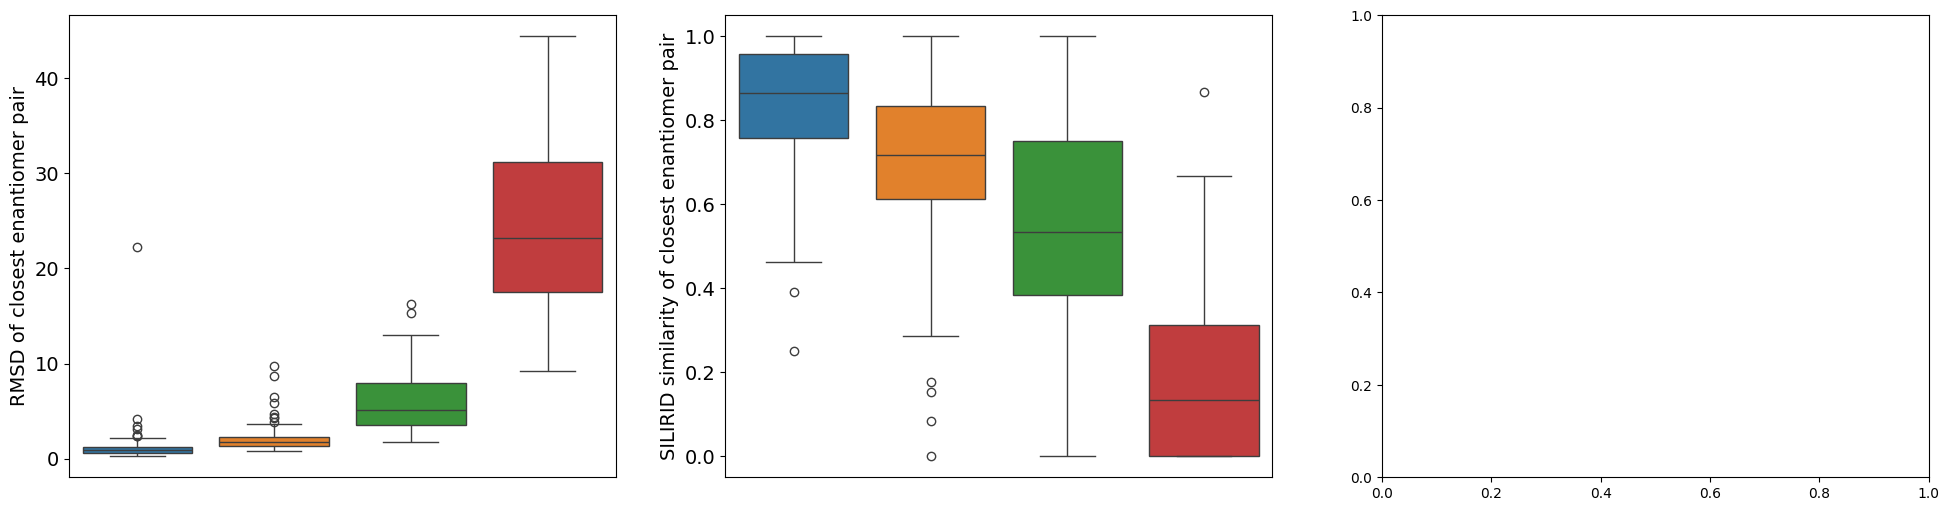

In [145]:
# --- Ensure manual_label is treated as string everywhere (fixes legend lookup) ---
threshold_training_table["manual_label"] = threshold_training_table["manual_label"].astype(str)

labels_sorted = sorted(
    threshold_training_table["manual_label"].dropna().unique(),
    key=lambda x: str(x)
)

category_label_map = {
    "1.1": "Same binding pocket with similar binding conformations (Cat. 1.1)",
    "1.2": "Same binding pocket with moderate conformational differences (Cat. 1.2)",
    "1.3": "Same binding pocket with distinct binding conformations (Cat. 1.3)",
    "2.0": "Distinct binding pocket (Cat. 2)",
}

palette_colors = sns.color_palette(
    "tab10" if len(labels_sorted) <= 10 else "tab20",
    n_colors=len(labels_sorted)
)
label_to_color = dict(zip(labels_sorted, palette_colors))

boxplot_columns = [
    ("closest_cross_tag_rmsd_A", "RMSD of closest enantiomer pair"),
    ("closest_cross_tag_similarity", "SILIRID similarity of closest enantiomer pair"),
]

# Set font sizes
label_fontsize = 14
tick_fontsize = 14
legend_fontsize = 14
title_fontsize = 17

# --- 3 panels: 2 boxplots + 1 scatter ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
legend_handles = None  # Will be filled for custom legend

# --- Panels 0 and 1: boxplots ---
for ax, (y, ylabel) in zip(axes[:2], boxplot_columns):
    sns.boxplot(
        data=threshold_training_table,
        x="manual_label",
        y=y,
        hue="manual_label",
        order=labels_sorted,
        hue_order=labels_sorted,
        palette=label_to_color,
        dodge=False,
        showfliers=True,
        ax=ax,
        legend=False,
    )
    ax.set_xlabel('', fontsize=label_fontsize)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)

    if ax is axes[0]:
        # Create one Patch per label with the long name
        legend_handles = [
            Patch(facecolor=label_to_color[code], label=category_label_map.get(str(code), str(code)))
            for code in labels_sorted
        ]

# --- Panel 2: scatterplot ---
plot_df = threshold_training_table[
    ["closest_cross_tag_rmsd_A", "closest_cross_tag_similarity", "manual_label"]
].copy()

plot_df["closest_cross_tag_distance"] = (
    1 - plot_df["closest_cross_tag_similarity"]
)
pretty_names = {
    "closest_cross_tag_rmsd_A": "RMSD of closest enantiomer pair",
    "closest_cross_tag_distance": "1 − SILIRID similarity",
    "manual_label": "Manual Label"
}
plot_df = plot_df.rename(columns=pretty_names)
# pretty_names = {
#     "closest_cross_tag_rmsd_A": "RMSD of closest enantiomer pair",
#     "closest_cross_tag_similarity": "SILIRID similarity of closest enantiomer pair",
#     "manual_label": "Manual Label"
# }
# plot_df = plot_df.rename(columns=pretty_names)

ax3 = axes[2]
sns.scatterplot(
    data=plot_df,
    x="RMSD of closest enantiomer pair",
    y="SILIRID similarity of closest enantiomer pair",
    hue="Manual Label",
    hue_order=labels_sorted,
    palette=label_to_color,
    alpha=0.8,
    s=48,
    edgecolor="w",
    linewidth=0.3,
    ax=ax3,
    legend=False,  # suppress built-in legend, we use the shared custom one
)
ax3.set_xlabel("RMSD of closest enantiomer pair", fontsize=label_fontsize)
ax3.set_ylabel("SILIRID similarity of closest enantiomer pair", fontsize=label_fontsize)
ax3.tick_params(axis='x', labelsize=tick_fontsize)
ax3.tick_params(axis='y', labelsize=tick_fontsize)

# --- Single shared legend for all 3 panels ---
leg = None
if legend_handles is not None:
    leg = fig.legend(
        handles=legend_handles,
        title="Category",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=len(labels_sorted),
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
    )

plt.tight_layout(rect=[0, 1.5, 2, 1])

# --- To save the legend into the .png file, use bbox_extra_artists and bbox_inches="tight" ---
# See: https://matplotlib.org/stable/users/explain/axes/legends.html#saving-a-figure-with-a-legend-outside-the-axes
extra_artists = [leg] if leg is not None else None
plt.savefig('../Data/Figures/RMSD_vs_similarity_boxplot.png', dpi=300,
            bbox_extra_artists=extra_artists, bbox_inches="tight")
plt.show()

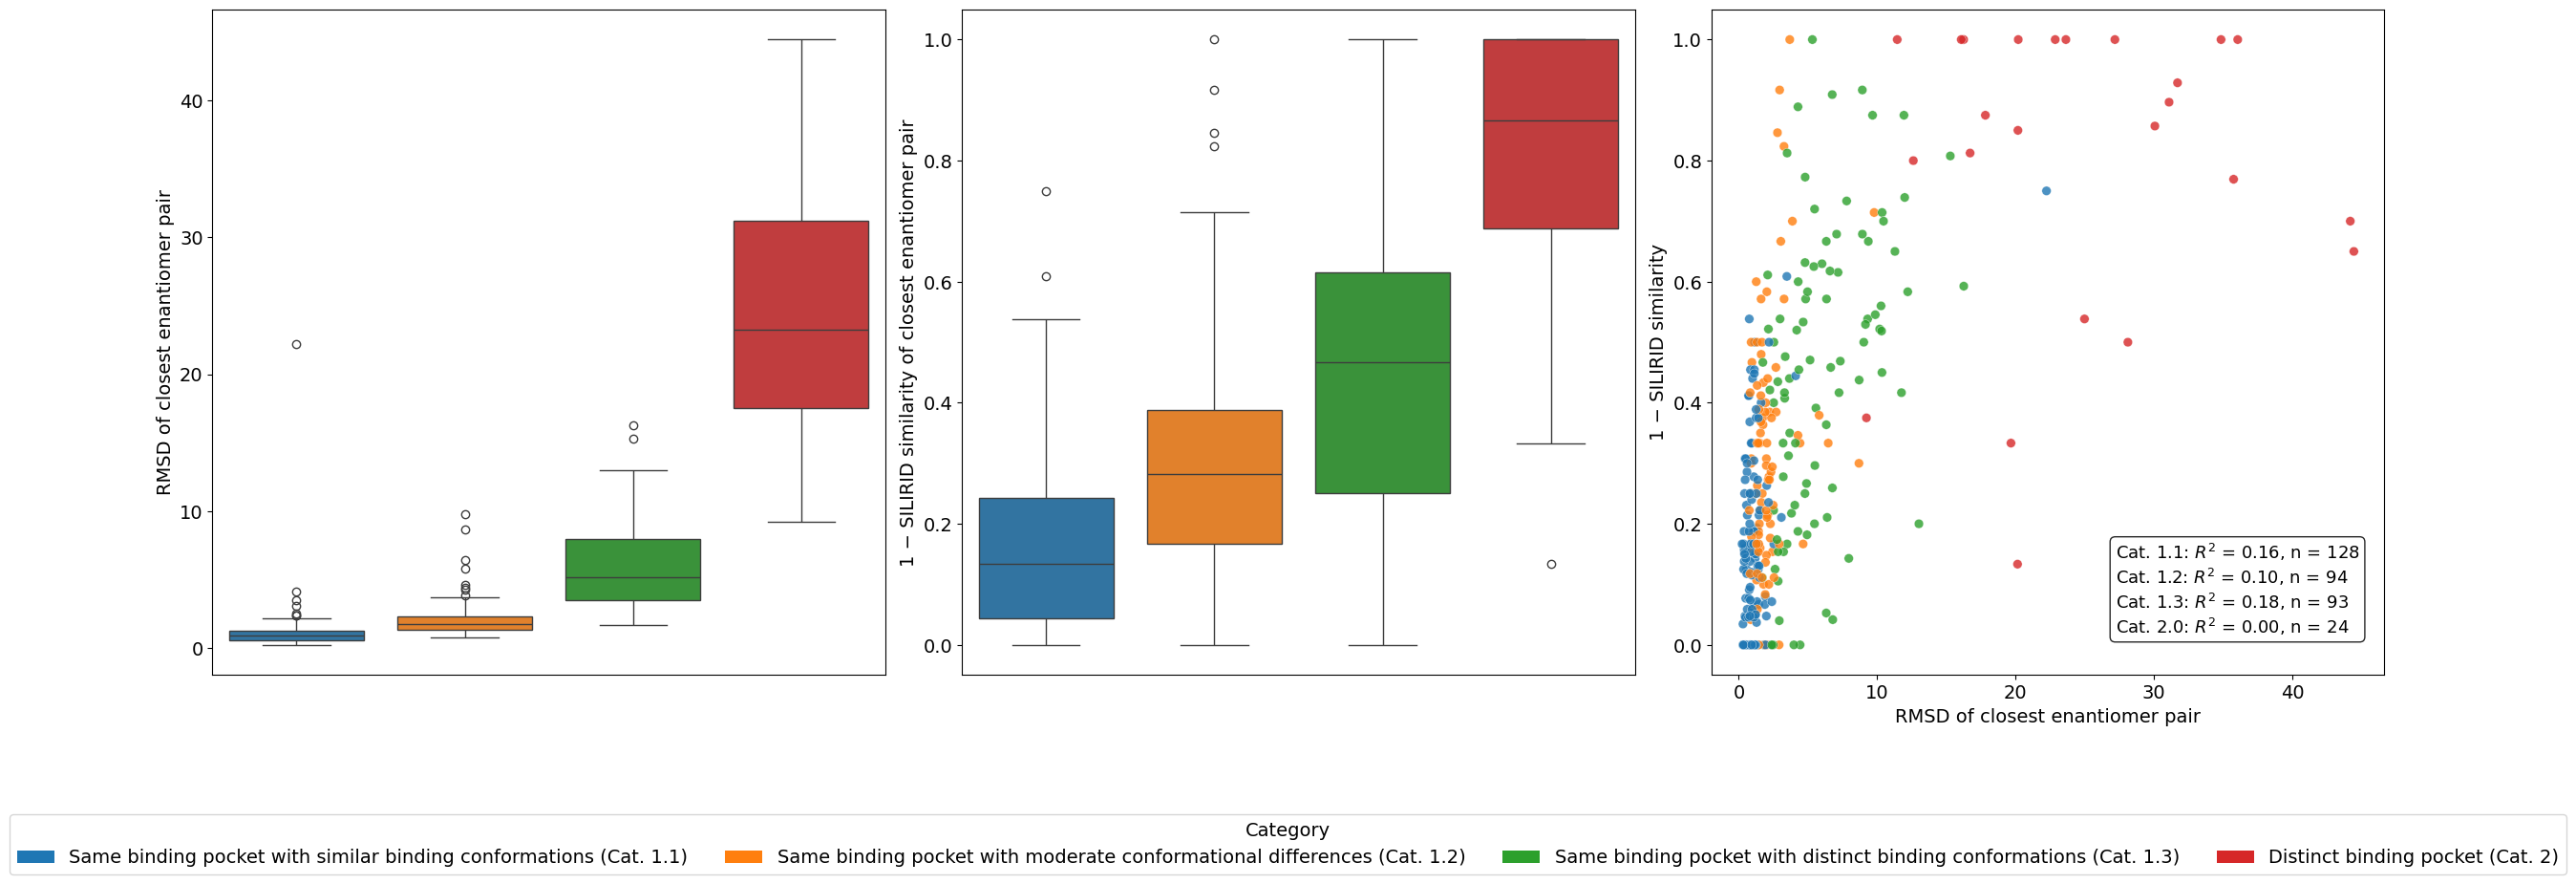

In [195]:
from scipy.stats import linregress
threshold_training_table["manual_label"] = (
    threshold_training_table["manual_label"].astype(str)
)
threshold_training_table["closest_cross_tag_distance"] = (
    1 - threshold_training_table["closest_cross_tag_similarity"]
)
labels_sorted = sorted(
    threshold_training_table["manual_label"].dropna().unique(),
    key=lambda x: str(x)
)

category_label_map = {
    "1.1": "Same binding pocket with similar binding conformations (Cat. 1.1)",
    "1.2": "Same binding pocket with moderate conformational differences (Cat. 1.2)",
    "1.3": "Same binding pocket with distinct binding conformations (Cat. 1.3)",
    "2.0": "Distinct binding pocket (Cat. 2)",
}

palette_colors = sns.color_palette(
    "tab10" if len(labels_sorted) <= 10 else "tab20",
    n_colors=len(labels_sorted)
)
label_to_color = dict(
    zip(labels_sorted, palette_colors)
)
boxplot_columns = [
    (
        "closest_cross_tag_rmsd_A",
        "RMSD of closest enantiomer pair"
    ),
    (
        "closest_cross_tag_distance",
        "1 − SILIRID similarity of closest enantiomer pair"
    ),
]
label_fontsize = 14
tick_fontsize = 14
legend_fontsize = 14
title_fontsize = 17
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 6)
)
legend_handles = None
for ax, (y, ylabel) in zip(
    axes[:2],
    boxplot_columns
):
    sns.boxplot(
        data=threshold_training_table,
        x="manual_label",
        y=y,
        hue="manual_label",
        order=labels_sorted,
        hue_order=labels_sorted,
        palette=label_to_color,
        dodge=False,
        showfliers=True,
        ax=ax,
        legend=False,
    )
    ax.set_xlabel(
        "",
        fontsize=label_fontsize
    )
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylabel(
        ylabel,
        fontsize=label_fontsize
    )
    ax.tick_params(
        axis="y",
        labelsize=tick_fontsize
    )
    if ax is axes[0]:
        legend_handles = [
            Patch(
                facecolor=label_to_color[code],
                label=category_label_map.get(
                    str(code),
                    str(code)
                )
            )
            for code in labels_sorted
        ]
plot_df = threshold_training_table[
    [
        "closest_cross_tag_rmsd_A",
        "closest_cross_tag_distance",
        "manual_label"
    ]
].copy()
pretty_names = {
    "closest_cross_tag_rmsd_A":
        "RMSD of closest enantiomer pair",

    "closest_cross_tag_distance":
        "1 − SILIRID similarity",

    "manual_label":
        "Manual Label"
}
plot_df = plot_df.rename(
    columns=pretty_names
)
regression_results = {}
for label in labels_sorted:
    class_df = plot_df[
        plot_df["Manual Label"] == str(label)
    ].dropna(
        subset=[
            "RMSD of closest enantiomer pair",
            "1 − SILIRID similarity"
        ]
    )
    x = class_df[
        "RMSD of closest enantiomer pair"
    ]
    y = class_df[
        "1 − SILIRID similarity"
    ]
    result = linregress(
        x,
        y
    )
    regression_results[str(label)] = {
        "r": result.rvalue,
        "r2": result.rvalue ** 2,
        "slope": result.slope,
        "intercept": result.intercept,
        "p_value": result.pvalue,
        "n": len(class_df)
    }
# print("\nRegression results by category:")
# for label in labels_sorted:
#     results = regression_results[str(label)]
#     if results["r2"] is not None:
#         print(
#             f"Category {label}: "
#             f"n = {results['n']}, "
#             f"r = {results['r']:.3f}, "
#             f"R² = {results['r2']:.3f}, "
#             f"slope = {results['slope']:.3f}, "
#             f"p = {results['p_value']:.3e}"
#         )
#     else:
#         print(
#             f"Category {label}: "
#             f"n = {results['n']} "
#             f"(not enough data for regression)"
#         )
ax3 = axes[2]
sns.scatterplot(
    data=plot_df,
    x="RMSD of closest enantiomer pair",
    y="1 − SILIRID similarity",
    hue="Manual Label",
    hue_order=labels_sorted,
    palette=label_to_color,
    alpha=0.8,
    s=48,
    edgecolor="w",
    linewidth=0.3,
    ax=ax3,
    legend=False,
)
stats_lines = []
for label in labels_sorted:
    results = regression_results[str(label)]
    if results["r2"] is not None:
        stats_lines.append(
            f"Cat. {label}: "
            f"$R^2$ = {results['r2']:.2f}, "
            f"n = {results['n']}"
        )
    else:
        stats_lines.append(
            f"Cat. {label}: "
            f"insufficient data "
            f"(n = {results['n']})"
        )
stats_text = "\n".join(
    stats_lines
)
ax3.text(
    0.60,
    0.20,
    stats_text,
    transform=ax3.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

ax3.set_xlabel(
    "RMSD of closest enantiomer pair",
    fontsize=label_fontsize
)
ax3.set_ylabel(
    "1 − SILIRID similarity",
    fontsize=label_fontsize
)
ax3.tick_params(
    axis="x",
    labelsize=tick_fontsize
)
ax3.tick_params(
    axis="y",
    labelsize=tick_fontsize
)

leg = None
if legend_handles is not None:

    leg = fig.legend(
        handles=legend_handles,
        title="Category",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(labels_sorted),
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
    )

plt.tight_layout(
    rect=[0, 0.2, 1, 1.5]
)

extra_artists = (
    [leg]
    if leg is not None
    else None
)

plt.savefig(
    "../Data/Figures/RMSD_vs_similarity_boxplot.png",
    dpi=300,
    bbox_extra_artists=extra_artists,
    bbox_inches="tight"
)
plt.show()

Descriptor bias that related to the molecule size
1. R and S enantiomers are overlapping with each other, also at the same time it have alternative structures
2. R and S enantiomers are overlapping with each other, should go to massive change
3. R and S enantiomers are overlapping with each other
4. wrongly assign, should go to massive change
5. the enantiomer pairs' molecule size is rather small, even it's SILIRID is low, it doesn't have the massive conformation change comparing to otehrs
6. R and S enantiomers are overlapping with each other
7. the enantiomer pairs' molecule size is relatively small
8. one enantiomer have no interaction with the pocket but the other have one

In [22]:
# --- Ensure manual_label is treated as string everywhere (fixes legend lookup) ---
threshold_training_table["manual_label"] = threshold_training_table["manual_label"].astype(str)

labels_sorted = sorted(
    threshold_training_table["manual_label"].dropna().unique(),
    key=lambda x: str(x)
)

category_label_map = {
    "1.1": "Same binding pocket with similar binding conformations (Cat. 1.1)",
    "1.2": "Same binding pocket with moderate conformational differences (Cat. 1.2)",
    "1.3": "Same binding pocket with distinct binding conformations (Cat. 1.3)",
    "2.0": "Distinct binding pocket (Cat. 2)",
}

palette_colors = sns.color_palette(
    "tab10" if len(labels_sorted) <= 10 else "tab20",
    n_colors=len(labels_sorted)
)
label_to_color = dict(zip(labels_sorted, palette_colors))

boxplot_columns = [
    ("closest_cross_tag_rmsd_A", "RMSD of closest enantiomer pair"),
    ("closest_cross_tag_similarity", "SILIRID similarity of closest enantiomer pair"),
]

# Set font sizes
label_fontsize = 14
tick_fontsize = 14
legend_fontsize = 14
title_fontsize = 17

# --- Collect outliers for SILIRID similarity boxplot (panel 1) ---
outlier_rows = []

# For each manual_label, compute IQR and get outliers for 'closest_cross_tag_similarity'
for label in labels_sorted:
    group = threshold_training_table[threshold_training_table["manual_label"] == label]
    col = "closest_cross_tag_similarity"
    vals = group[col].dropna()
    if len(vals) < 1:
        continue
    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (vals < lower) | (vals > upper)
    outlier_indices = vals[mask].index
    outlier_rows.append(group.loc[outlier_indices])

if outlier_rows:
    outlier_df = pd.concat(outlier_rows)
    # Export outliers to file (you can adjust the path as needed)
    outlier_df.to_csv("../Data/Figures/SILIRID_similarity_outliers.csv", index=False)
else:
    outlier_df = pd.DataFrame()  # empty, no outliers

In [23]:
outlier_df

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_pair_mean_distance_A,closest_cross_tag_min_atom_distance_A,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,cross_tag_distance_slope,n_atoms_cross_tag_slope,category_reason,n_m0_structures,n_m1_structures,similarity_metric
138,g000807_inchi_ef18922c3f_inconsistent.csv,1,1.1,from_complex_categories,interaction_1e2i_APS_B_510_m0.tsv,interaction_1e2i_ARP_B_511_m1.tsv,3.445937,3.151628,3.472281,0.391304,1.045006,14.0,manual_curation_1.1,1,2,structure_silirid_similarity
239,g001203_inchi_8b3a40b56d_inconsistent.csv,1,1.1,from_complex_categories,interaction_4xdk_405_A_608_m0.tsv,interaction_4xdk_408_A_606_m1.tsv,21.640998,12.403820,22.231554,0.250000,16.553835,21.0,manual_curation_1.1,1,3,structure_silirid_similarity
20,g000258_inchi_9953a9371d_inconsistent.csv,1,1.2,from_complex_categories,interaction_4tyb_3B1_A_601_m0.tsv,interaction_4tyb_3B1_C_601_m1.tsv,2.748835,0.622881,3.267722,0.176471,5.260350,15.0,manual_curation_1.2,1,3,structure_silirid_similarity
70,g000533_inchi_a4385e0ec8_inconsistent.csv,1,1.2,from_complex_categories,interaction_4kzb_NZ2_A_402_m0.tsv,interaction_4kzb_NZ3_B_402_m1.tsv,3.399400,1.319227,3.683733,0.000000,4.453187,16.0,manual_curation_1.2,5,1,structure_silirid_similarity
308,g001738_inchi_2c482d395a_inconsistent.csv,1,1.2,from_complex_categories,interaction_8ke2_FX9_A_504_m0.tsv,interaction_8ke3_FXC_A_504_m1.tsv,2.582662,0.953445,2.797839,0.153846,3.473143,16.0,manual_curation_1.2,1,1,structure_silirid_similarity
310,g001740_inchi_c47f2ece18_inconsistent.csv,1,1.2,from_complex_categories,interaction_8ke6_FCL_A_504_m0.tsv,interaction_8ke5_FXL_A_504_m1.tsv,2.891572,2.193017,2.954774,0.083333,1.795521,13.0,manual_curation_1.2,1,1,structure_silirid_similarity
346,g001957_inchi_95048f8833_inconsistent.csv,1,2.0,from_complex_categories,interaction_6b5v_ECL_B_1001_m0.tsv,interaction_8tf3_ECN_A_804_m1.tsv,20.018010,18.122459,20.140796,0.866667,6.254753,24.0,manual_curation_2,4,8,structure_silirid_similarity


# Distribution of the physicochemical properties across categories

In [24]:
enantiomer_structures = '../Data/chiral_classification_results/Drug_likeness_evaluation/filtered_enantiomer_with_uniprot_UniProtID_updated.sdf'
manual_check_folder = '../Data/Manual_curation'
all_matched_records = []
for file in os.listdir(manual_check_folder):
    if file.endswith('.csv') and not 'manualcheck_invalid' in file:
        file_path = os.path.join(manual_check_folder, file)
        df = pd.read_csv(file_path, delimiter='\t')
        df_non4letter_title = df[df['Title'].astype(str).str.len() != 4]
        grouped = df_non4letter_title.groupby('group')
        for group_name, group_df in grouped:
            for idx, row in group_df.iterrows():
                ids = row['ID']
                if pd.notna(ids):
                    if isinstance(ids, str) and ids.startswith('[') and ids.endswith(']'):
                        try:
                            ids_list = ast.literal_eval(ids)
                        except Exception:
                            ids_list = []
                    else:
                        ids_list = [ids]
                    for pdb_item in ids_list:
                        matched_record = {
                            'group': group_name,
                            'category': row['category_manual_check'],
                            'pdb_item': pdb_item,
                            'pdb_code': None,
                            'ligand_name': None,
                            'matched': False,
                            'pdbbind_info': None,
                        }
                        if isinstance(pdb_item, str) and '_' in pdb_item:
                            split_pdb = pdb_item.split('_')
                            if len(split_pdb) >= 3:
                                pdb_code = split_pdb[1].strip().lower()
                                ligand_name = split_pdb[2].strip()
                                m_layer = split_pdb[5].strip()
                                matched_record['pdb_code'] = pdb_code
                                matched_record['ligand_name'] = ligand_name
                                matched_record['m_layer'] = m_layer
                            all_matched_records.append(matched_record)
matched_df = pd.DataFrame(all_matched_records)
matched_df.head(10)

,group,category,pdb_item,pdb_code,ligand_name,matched,pdbbind_info,m_layer
0,{'g000001_b55a025257'},1.2.1,A0A009KIJ4_7pqm_80S_B_301_m0,7pqm,80S,False,None,m0
1,{'g000001_b55a025257'},1.2.1,A0A009KIJ4_7pqm_80S_A_301_m0,7pqm,80S,False,None,m0
2,{'g000001_b55a025257'},1.2.1,A0A009KIJ4_7pql_80S_B_301_m0,7pql,80S,False,None,m0
3,{'g000001_b55a025257'},1.2.1,A0A009KIJ4_7pql_81N_B_302_m1,7pql,81N,False,None,m1
4,{'g000001_b55a025257'},1.2.1,A0A009KIJ4_7pql_80S_A_301_m0,7pql,80S,False,None,m0
5,{'g000001_b55a025257'},1.2.1,A0A009KIJ4_7pql_81N_A_302_m1,7pql,81N,False,None,m1
6,{'g000139_bd00065b41'},1.2.1,A0ACD6B9D0_8abw_LHX_A_405_m0,8abw,LHX,False,None,m0
7,{'g000139_bd00065b41'},1.2.1,A0ACD6B9D0_8abw_LJC_A_404_m1,8abw,LJC,False,None,m1
8,{'g000140_ec7c705005'},1.2.1,A0ACD6B9D0_8abv_LJU_A_304_m0,8abv,LJU,False,None,m0
9,{'g000140_ec7c705005'},1.2.1,A0ACD6B9D0_8abv_LJL_A_305_m1,8abv,LJL,False,None,m1


In [25]:
enantiomer_mols = {}
SDMolSupplier_enantiomers = Chem.SDMolSupplier(enantiomer_structures)
for mol in SDMolSupplier_enantiomers:
    if mol is not None and mol.HasProp("_Name"):
        enantiomer_mols[mol.GetProp("_Name")] = mol

represenetative_enantiomer_mols = []
visited_groups = set()
for idx, (identifier, group, category) in enumerate(zip(matched_df['pdb_item'],
                                                    matched_df['group'], matched_df['category'])):
    if group in visited_groups:
        continue  # Skip if we've already collected an entry for this group
    parts = identifier.split('_')
    enantiomer_identifier = '_'.join(parts[1:-1])
    mol = enantiomer_mols.get(enantiomer_identifier, None)
    if mol is not None:
        represenetative_enantiomer_mols.append((enantiomer_identifier, mol, group, category))
        visited_groups.add(group)
    else:
        print(f"No matching structure found for: {enantiomer_identifier}")

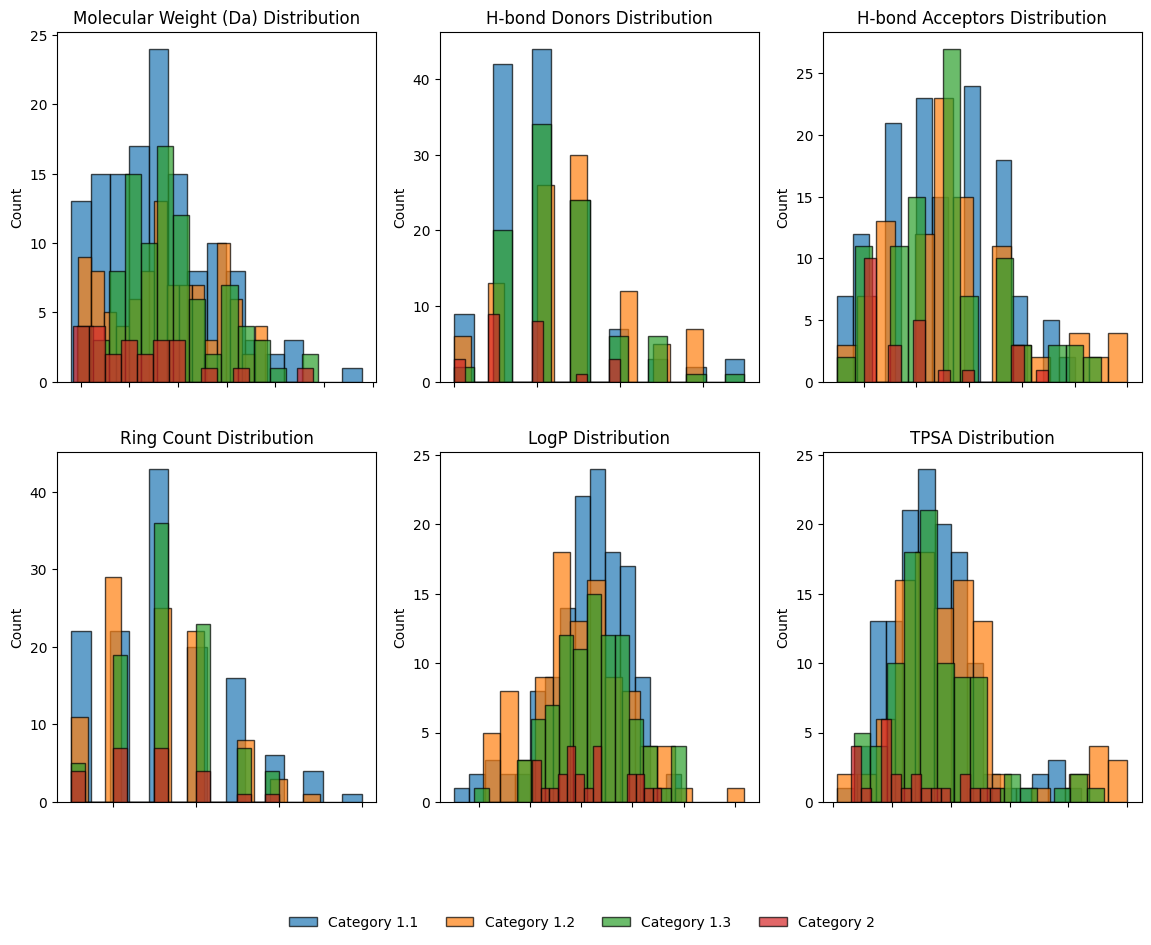

In [26]:
# Category remapping function
def remap_category(cat):
    cat = str(cat)
    if cat == "1.2.1":
        return "1.1"
    elif cat == "1.2.2":
        return "1.2"
    elif cat == "1.2.3":
        return "1.3"
    elif cat == "1.1":
        return "2.0"
    else:
        return cat

# Create the set of unique categories after remapping
unique_cats = sorted(set(remap_category(category) for _, _, _, category in represenetative_enantiomer_mols))
palette_colors = sns.color_palette("tab10", n_colors=len(unique_cats))
cat_color_dict = dict(zip(unique_cats, palette_colors))

mol_weights = []
hbd_list = []
hba_list = []
ring_count_list = []
logp_list = []
tpsa_list = []
categories = []

for identifier, mol, group, category in represenetative_enantiomer_mols:
    mol_weights.append(Descriptors.MolWt(mol))
    hbd_list.append(Descriptors.NumHDonors(mol))
    hba_list.append(Descriptors.NumHAcceptors(mol))
    ring_count_list.append(Descriptors.RingCount(mol))
    logp_list.append(Descriptors.MolLogP(mol))
    tpsa_list.append(Descriptors.TPSA(mol))
    cat_str = remap_category(category)
    categories.append(cat_str)

df = pd.DataFrame({
    'MolecularWeight': mol_weights,
    'HBDonors': hbd_list,
    'HBAcceptors': hba_list,
    'RingCount': ring_count_list,
    'LogP': logp_list,
    'TPSA': tpsa_list,
    'Category': categories
})
properties = [
    ('MolecularWeight', 'Molecular Weight (Da)'),
    ('HBDonors', 'H-bond Donors'),
    ('HBAcceptors', 'H-bond Acceptors'),
    ('RingCount', 'Ring Count'),
    ('LogP', 'LogP'),
    ('TPSA', 'TPSA')
]
num_properties = len(properties)
ncols = 3
nrows = (num_properties + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

handles_labels_set = False
handles = None
labels = None
for i, (prop, label) in enumerate(properties):
    if i >= len(axes):
        break
    ax = axes[i]
    local_handles = []
    local_labels = []
    for j, cat in enumerate(unique_cats):
        prop_values = df[df['Category'] == cat][prop]
        n, bins, patches = ax.hist(
            prop_values, bins=15, alpha=0.70, 
            label=f'Category {cat}',
            color=cat_color_dict[cat], 
            edgecolor='black'
        )
        if not handles_labels_set and len(patches) > 0:
            local_handles.append(patches[0])
            local_labels.append(f'Category {cat}')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Distribution')
    ax.set_xticklabels([])  # Remove x ticks label
    if not handles_labels_set:
        handles = local_handles
        labels = local_labels
        handles_labels_set = True
for j in range(num_properties, len(axes)):
    fig.delaxes(axes[j])
if handles is not None and labels is not None:
    fig.legend(
        handles, labels,
        loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=len(labels), frameon=False
    )
plt.show()

# pdf convertion

In [14]:
from pdf2image import convert_from_path
import os

pdf_path = '/home/hzhang/Downloads/Figures-8.pdf'
output_folder = '../Data/Figures'

# Convert all pages to images and save them
images = convert_from_path(pdf_path, dpi=300)

n_pages = len(images)
# Save only the last four pages as images
for idx in range(n_pages-5, n_pages+1):
    page_image = images[idx - 1]
    output_path = os.path.join(output_folder, f"Figures_page{idx}.png")
    page_image.save(output_path, "PNG")
    print(f"Saved: {output_path}")

Saved: ../Data/Figures/Figures_page7.png
Saved: ../Data/Figures/Figures_page8.png
Saved: ../Data/Figures/Figures_page9.png
Saved: ../Data/Figures/Figures_page10.png
Saved: ../Data/Figures/Figures_page11.png
Saved: ../Data/Figures/Figures_page12.png


Data

In [44]:
manualcheck_category = '../../Data_BindingModeCategorization/manualcheck_categories.csv'
manualcheck_category_df = pd.read_csv(manualcheck_category)

In [ ]:
# filtered_df = manualcheck_category_df[
#     manualcheck_category_df['ID'].notna() &
#     manualcheck_category_df['PDB RESOLUTION'].isna()
# ]
# filtered_df.to_csv('../../Data_BindingModeCategorization/filtered_manualcheck_categories.csv')

# SILIRID quantification

In [2]:
threshold_training_table_updated = pd.read_csv('../Data/Categorization/threshold_training_table.csv')
silirid_fingerprint_slot = pd.read_csv('../Data/Categorization/silirid_fingerprint_slots.csv')
display(threshold_training_table_updated.head(5))
display(silirid_fingerprint_slot.head(5))

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,category_reason,n_m0_structures,n_m1_structures,similarity_metric,silirid_vector_length,silirid_count_cap
0,g000001_inchi_b55a025257_inconsistent.csv,1,1.1,from_complex_categories,NaN,NaN,NaN,NaN,NaN,NaN,manual_curation_1.1;inconsistent_atom_count,4,2,structure_silirid_similarity,160,3
1,g000013_inchi_cb46fef414_inconsistent.csv,1,1.3,from_complex_categories,interaction_6b52_OAQ_A_302_m0.tsv,interaction_5tix_OQR_B_302_m1.tsv,3.218487,0.722222,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,5,2,structure_silirid_similarity,160,3
2,g000045_inchi_359154acb2_inconsistent.csv,1,1.3,from_complex_categories,interaction_6c92_EQJ_A_401_m0.tsv,interaction_5dj3_5DK_C_500_m1.tsv,2.537710,0.500000,"0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,3,0,...","0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,2,0,...",manual_curation_1.3,12,1,structure_silirid_similarity,160,3
3,g000049_inchi_6924aac1df_inconsistent.csv,1,1.3,from_complex_categories,interaction_5kd6_LBU_B_501_m0.tsv,interaction_5kcy_XBU_B_501_m1.tsv,4.796130,0.227273,"0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,1,3,structure_silirid_similarity,160,3
4,g000066_inchi_31f4cbeb1f_inconsistent.csv,1,1.2,from_complex_categories,interaction_6e7u_HX7_D_402_m0.tsv,interaction_6e7v_T88_D_502_m1.tsv,2.038000,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.2,2,2,structure_silirid_similarity,160,3


,slot_index,amino_acid,feature_type
0,0,ALA,HYDROPHOBIC
1,1,ALA,AROMATIC
2,2,ALA,NEGATIVE_IONIZABLE
3,3,ALA,POSITIVE_IONIZABLE
4,4,ALA,H_BOND_DONOR


Pharmacophore examples searching

In [3]:
top_five = (
    threshold_training_table_updated[threshold_training_table_updated['manual_label'] == 1.1]
    .sort_values(by='closest_cross_tag_similarity', ascending=False)
    .head(5)
)
top_five

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,category_reason,n_m0_structures,n_m1_structures,similarity_metric,silirid_vector_length,silirid_count_cap
10,g000144_inchi_e41f15b5ba_inconsistent.csv,1,1.1,from_complex_categories,interaction_7km9_WPJ_A_202_m0.tsv,interaction_7km7_WPD_A_202_m1.tsv,0.596462,1.0,"0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,3,structure_silirid_similarity,160,3
17,g000212_inchi_2f85649d80_inconsistent.csv,1,1.1,from_complex_categories,interaction_7yy8_3IL_B_201_m0.tsv,interaction_7yy8_4Z9_C_201_m1.tsv,0.910342,1.0,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,1,structure_silirid_similarity,160,3
50,g000448_inchi_d463a70235_consistent.csv,1,1.1,from_complex_categories,interaction_5z8r_99O_A_201_m0.tsv,interaction_5z8g_99L_A_201_m1.tsv,0.491896,1.0,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...",manual_curation_1.1,1,1,structure_silirid_similarity,160,3
46,g000444_inchi_c672a921c7_inconsistent.csv,1,1.1,from_complex_categories,interaction_6vsn_RG4_D_1201_m0.tsv,interaction_6vnk_RXT_D_1201_m1.tsv,0.535079,1.0,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,4,5,structure_silirid_similarity,160,3
98,g000638_inchi_0b69476109_inconsistent.csv,1,1.1,from_complex_categories,interaction_3n8z_FLP_A_701_m0.tsv,interaction_3n8w_FLP_A_802_m1.tsv,0.426256,1.0,"0,0,0,0,0,0,0,0,0,3,3,0,0,2,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,3,3,0,0,2,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,8,1,structure_silirid_similarity,160,3


In [5]:
middle_five = (
    threshold_training_table_updated[threshold_training_table_updated['manual_label'] == 1.1]
    .sort_values(by='closest_cross_tag_similarity', ascending=False)
)

middle_index = len(middle_five) // 2
start = max(0, middle_index - 2)
end = start + 5

middle_five_subset = middle_five.iloc[start:end]
middle_five_subset

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,category_reason,n_m0_structures,n_m1_structures,similarity_metric,silirid_vector_length,silirid_count_cap
100,g000643_inchi_7afe262ba5_inconsistent.csv,1,1.1,from_complex_categories,interaction_7q1o_9CI_A_605_m0.tsv,interaction_7q1p_8UW_A_606_m1.tsv,0.827606,0.862069,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,1,structure_silirid_similarity,160,3
179,g001014_inchi_ec8bff652c_inconsistent.csv,1,1.1,from_complex_categories,interaction_6q7b_HO5_A_1001_m0.tsv,interaction_6q7e_HMW_A_1001_m1.tsv,0.396353,0.862069,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,1,structure_silirid_similarity,160,3
232,g001166_inchi_c0fb4970f3_inconsistent.csv,1,1.1,from_complex_categories,interaction_6q90_HFK_C_402_m0.tsv,interaction_6q91_HFK_C_402_m1.tsv,0.511745,0.857143,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,2,3,structure_silirid_similarity,160,3
12,g000186_inchi_b4715436af_inconsistent.csv,1,1.1,from_complex_categories,interaction_7t5z_F6I_F_301_m0.tsv,interaction_7t5z_F6I_B_301_m1.tsv,1.183163,0.857143,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,2,4,structure_silirid_similarity,160,3
105,g000660_inchi_f655a74478_inconsistent.csv,1,1.1,from_complex_categories,interaction_6prc_CEB_L_502_m0.tsv,interaction_7prc_CET_L_502_m1.tsv,1.159793,0.850000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,1,structure_silirid_similarity,160,3


In [85]:
bottom_five = (
    threshold_training_table_updated[
        (threshold_training_table_updated['manual_label'] == 1.1) &
        (threshold_training_table_updated['closest_cross_tag_similarity'].notna())
    ]
    .sort_values(by='closest_cross_tag_similarity', ascending=True)
    .head(5)
)
bottom_five

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,category_reason,n_m0_structures,n_m1_structures,similarity_metric,silirid_vector_length,silirid_count_cap
239,g001203_inchi_8b3a40b56d_inconsistent.csv,1,1.1,from_complex_categories,interaction_4xdk_405_A_608_m0.tsv,interaction_4xdk_408_A_606_m1.tsv,22.231554,0.250000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,3,structure_silirid_similarity,160,3
138,g000807_inchi_ef18922c3f_inconsistent.csv,1,1.1,from_complex_categories,interaction_1e2i_APS_B_510_m0.tsv,interaction_1e2i_ARP_B_511_m1.tsv,3.472281,0.391304,"0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,2,structure_silirid_similarity,160,3
273,g001387_inchi_6be500f3b9_inconsistent.csv,1,1.1,from_complex_categories,interaction_9l90_U1C_A_1101_m0.tsv,interaction_9l9b_U1C_B_1102_m1.tsv,0.761237,0.461538,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...",manual_curation_1.1,3,1,structure_silirid_similarity,160,3
134,g000795_inchi_a51f266a34_inconsistent.csv,1,1.1,from_complex_categories,interaction_5saa_ZQD_A_402_m0.tsv,interaction_5saa_ZQD_B_402_m1.tsv,1.149977,0.500000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,1,structure_silirid_similarity,160,3
309,g001739_inchi_b1d80c0136_inconsistent.csv,1,1.1,from_complex_categories,interaction_8ke1_6CV_A_502_m0.tsv,interaction_8ke4_FXF_A_504_m1.tsv,2.190391,0.500000,"0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.1,1,1,structure_silirid_similarity,160,3


In [6]:
silirid_fingerprint_slot.columns

Index(['slot_index', 'amino_acid', 'feature_type'], dtype='object')

Quantification

In [7]:
def parse_silirid_string(s):
    """Parses a vector string from the table into a NumPy array."""
    if pd.isna(s):
        return np.array([])
    return np.array([int(x) for x in s.split(',')])

if {'closest_cross_tag_silirid_a', 'closest_cross_tag_silirid_b'}.issubset(threshold_training_table_updated.columns):
    # Prepare slot_info (for annotation on each slot index)
    if {'slot_index', 'amino_acid', 'feature_type'}.issubset(silirid_fingerprint_slot.columns):
        slot_info = silirid_fingerprint_slot[['slot_index', 'amino_acid', 'feature_type']].reset_index(drop=True)
    else:
        # fallback with just indices if info missing
        valid_rows = threshold_training_table_updated['closest_cross_tag_silirid_a'].dropna()
        n_slots = len(parse_silirid_string(valid_rows.iloc[0])) if len(valid_rows) > 0 else 0
        slot_info = pd.DataFrame({
            'slot_index': np.arange(n_slots),
            'amino_acid': ['UNK'] * n_slots,
            'feature_type': np.arange(n_slots)
        })

    # For each entry, calculate difference vector, get info and aggregate into new per-entry dataframe
    silirid_diff_info_entries = []
    for idx, row in threshold_training_table_updated.iterrows():
        a_vec = parse_silirid_string(row.get('closest_cross_tag_silirid_a', np.nan))
        b_vec = parse_silirid_string(row.get('closest_cross_tag_silirid_b', np.nan))
        if len(a_vec) > 0 and len(b_vec) > 0 and len(a_vec) == len(b_vec):
            if np.array_equal(a_vec, b_vec):
                # Vectors exist and are identical: add a special info row
                silirid_diff_info_entries.append({
                    'entry_index': idx,
                    'info_file': row.get('info_file', np.nan),
                    'slot_index': None,
                    'amino_acid': None,
                    'feature_type': None,
                    'difference': 0,
                    'manual_label': row.get('manual_label', np.nan),
                    'closest_cross_tag_similarity': row.get('closest_cross_tag_similarity', np.nan),
                    'identical': True
                })
            else:
                diff = np.abs(a_vec - b_vec)
                # For each nonzero difference, get the slot info
                for slot_idx, dval in enumerate(diff):
                    if dval != 0:
                        amino_acid = slot_info.loc[slot_idx, 'amino_acid'] if slot_idx < len(slot_info) else 'UNK'
                        feature_type = slot_info.loc[slot_idx, 'feature_type'] if slot_idx < len(slot_info) else 'UNK'
                        silirid_diff_info_entries.append({
                            'entry_index': idx,
                            'info_file': row.get('info_file', np.nan),
                            'diff_index': diff,
                            'slot_index': slot_idx,
                            'amino_acid': amino_acid,
                            'feature_type': feature_type,
                            'difference': dval,
                            'manual_label': row.get('manual_label', np.nan),
                            'closest_cross_tag_similarity': row.get('closest_cross_tag_similarity', np.nan),
                            'identical': False
                        })

    # Ensure DataFrame always has the 'identical' column, even if empty
    silirid_diff_info_df = pd.DataFrame(
        silirid_diff_info_entries,
        columns=[
            'entry_index', 'info_file', 'diff_index', 'slot_index', 'amino_acid', 'feature_type',
            'difference', 'manual_label', 'closest_cross_tag_similarity', 'identical'
        ]
    )
else:
    slot_info = None
    silirid_diff_info_df = pd.DataFrame(
        columns=[
            'entry_index', 'info_file', 'diff_index', 'slot_index', 'amino_acid', 'feature_type',
            'difference', 'manual_label', 'closest_cross_tag_similarity', 'identical'
        ]
    )  # empty dataframe for consistency

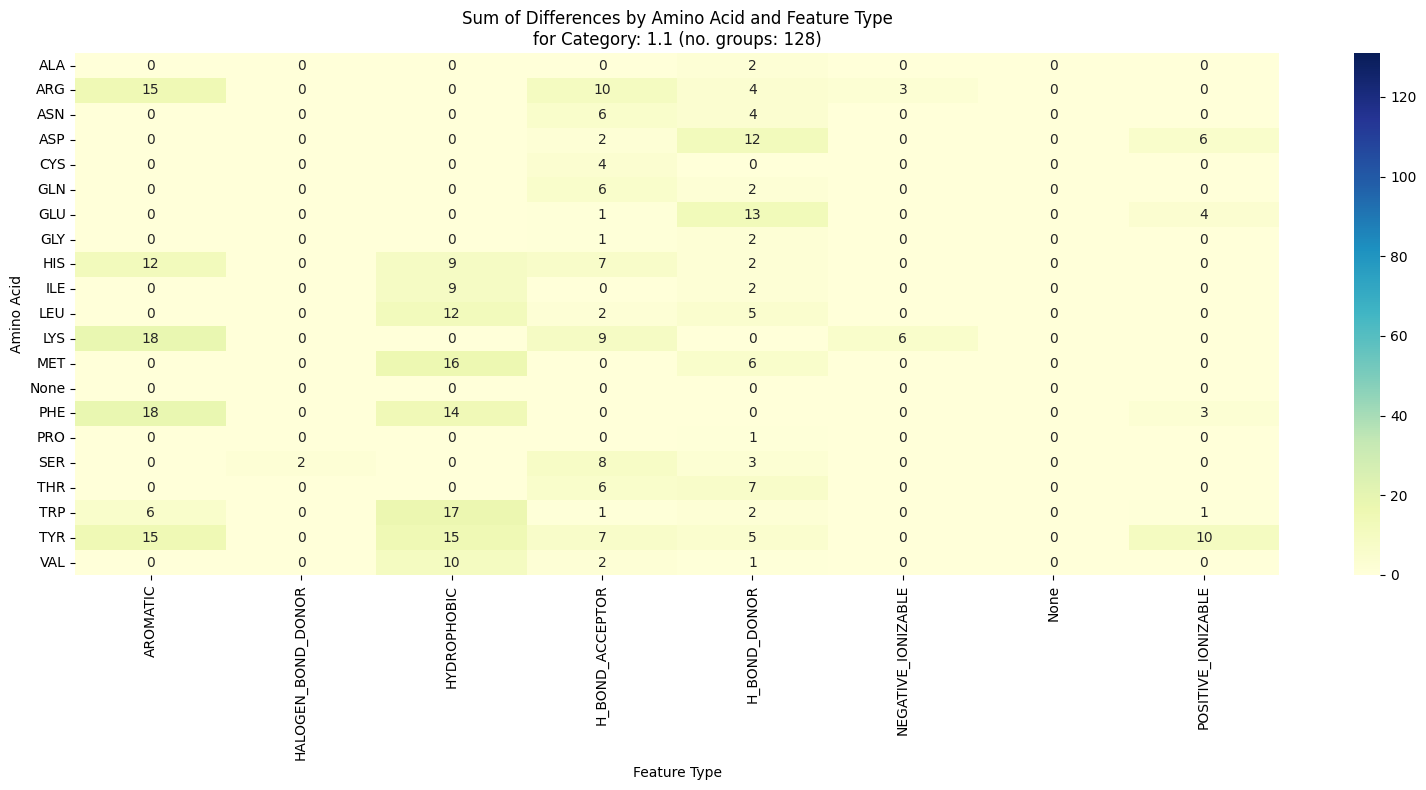

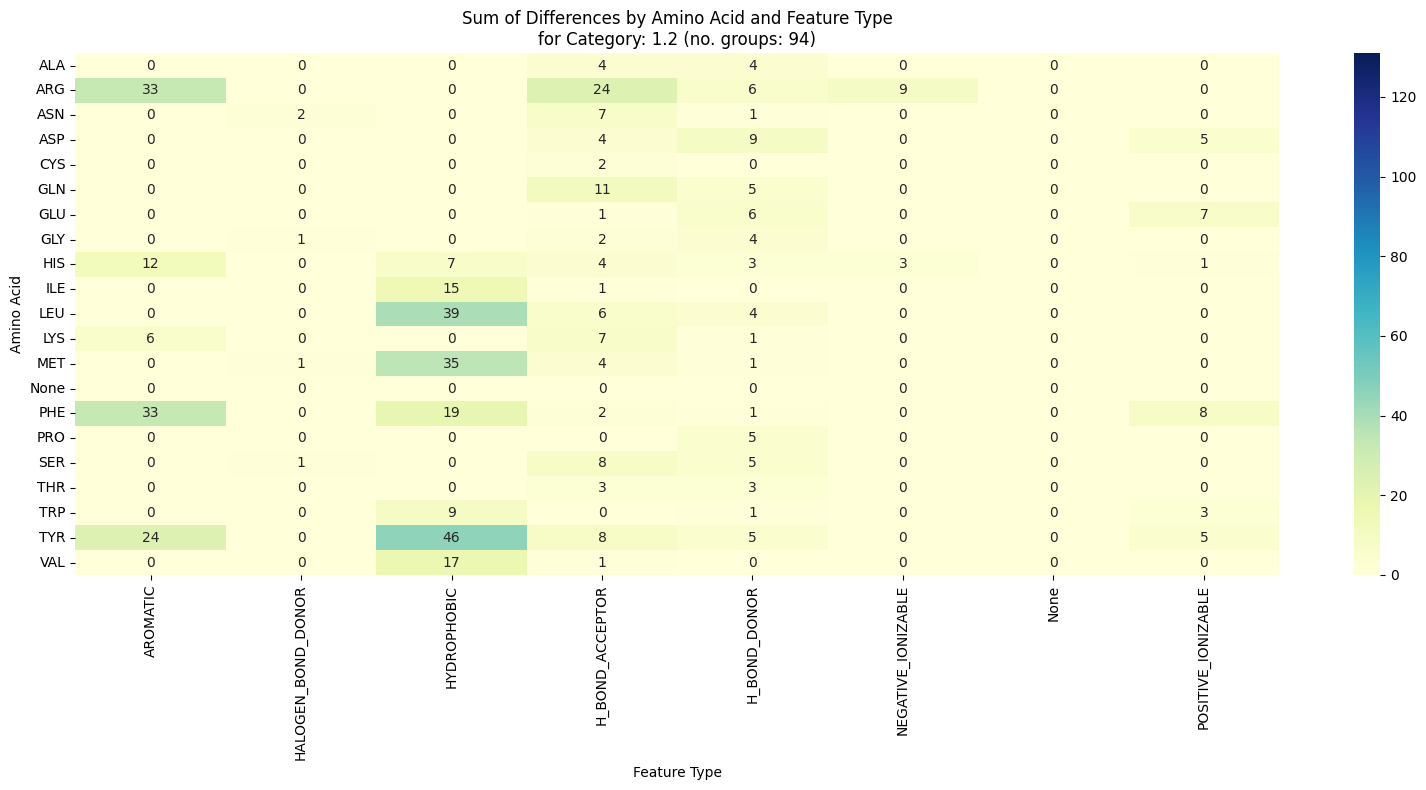

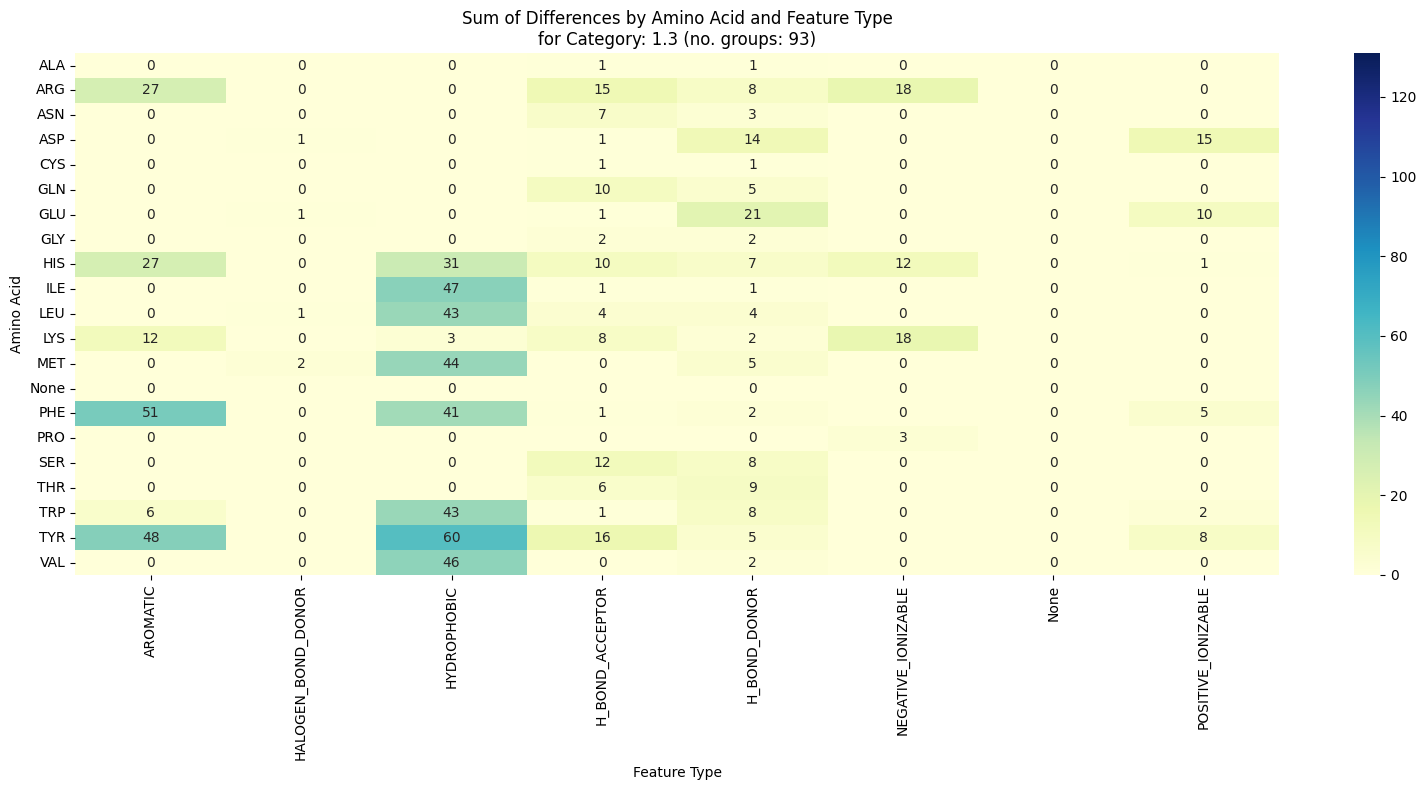

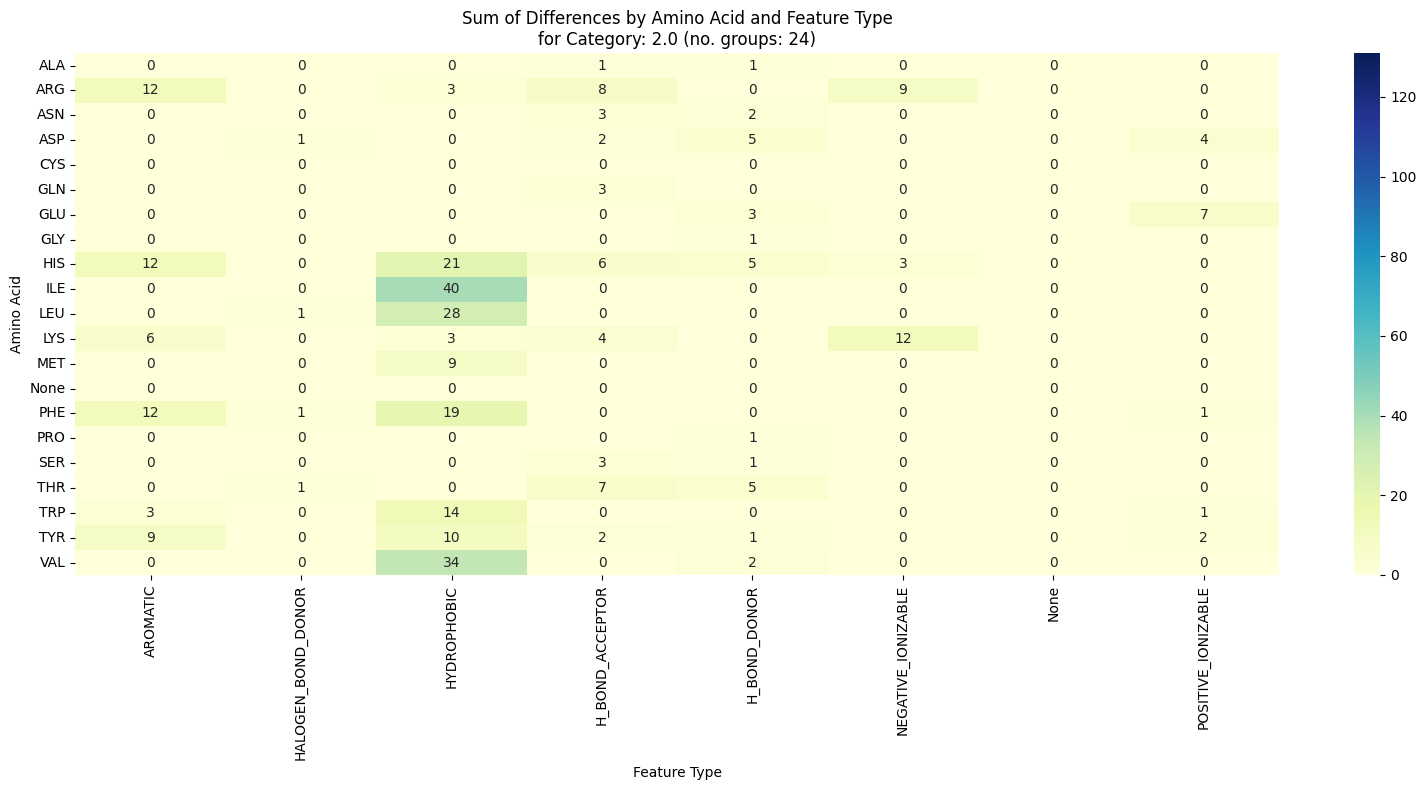

In [ ]:
unique_labels = silirid_diff_info_df['manual_label'].dropna().unique()

# Calculate global min and max for the heatmaps (for comparable colorbar scaling)
all_ac_features = silirid_diff_info_df.copy()
all_ac_features['amino_acid_feature'] = all_ac_features['amino_acid'].astype(str) + '_' + all_ac_features['feature_type'].astype(str)
feature_diff_counts_global = all_ac_features.groupby('amino_acid_feature')['difference'].sum().reset_index()
feature_diff_counts_global[['amino_acid', 'feature_type']] = feature_diff_counts_global['amino_acid_feature'].str.split('_', n=1, expand=True)
heatmap_data_global = feature_diff_counts_global.pivot(index='amino_acid', columns='feature_type', values='difference').fillna(0)
vmin = heatmap_data_global.values.min()
vmax = heatmap_data_global.values.max()

# Compute group counts for each category
group_counts_per_category = {}
if "info_file" in silirid_diff_info_df.columns:
    # A group is a unique info_file per category
    info_file_table = silirid_diff_info_df[['manual_label', 'info_file']].drop_duplicates()
    group_counts_per_category = (
        info_file_table.groupby('manual_label')['info_file']
        .nunique().to_dict()
    )

for category in sorted(unique_labels):
    category_df = silirid_diff_info_df[silirid_diff_info_df['manual_label'] == category]
    if category_df.empty:
        continue

    n_groups = group_counts_per_category.get(category, '?')
    category_df = category_df.copy()
    category_df['amino_acid_feature'] = category_df['amino_acid'].astype(str) + '_' + category_df['feature_type'].astype(str)
    feature_diff_counts_cat = category_df.groupby('amino_acid_feature')['difference'].sum().reset_index()
    feature_diff_counts_cat[['amino_acid', 'feature_type']] = feature_diff_counts_cat['amino_acid_feature'].str.split('_', n=1, expand=True)
    heatmap_data_cat = feature_diff_counts_cat.pivot(index='amino_acid', columns='feature_type', values='difference').fillna(0)

    # Reindex to have same rows/columns as global matrix, so missing aa/ft show as 0 instead of disappearing
    heatmap_data_cat = heatmap_data_cat.reindex(index=heatmap_data_global.index, columns=heatmap_data_global.columns, fill_value=0)

    plt.figure(figsize=(16, 8))
    sns.heatmap(
        heatmap_data_cat, annot=True, fmt=".0f", cmap="YlGnBu",
        vmin=vmin, vmax=vmax
    )
    plt.title(f'Sum of Differences by Amino Acid and Feature Type\n'
            f'for Category: {category} (no. groups: {n_groups})')
    plt.xlabel('Feature Type')
    plt.ylabel('Amino Acid')
    plt.tight_layout()
    plt.show()

# Extreme cases

low RMSD with low SILIRID similarity

In [8]:
threshold_training_table_updated[threshold_training_table_updated['manual_label'] == 2].sort_values(by='closest_cross_tag_similarity', ascending=False).head(30)

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,category_reason,n_m0_structures,n_m1_structures,similarity_metric,silirid_vector_length,silirid_count_cap
346,g001957_inchi_95048f8833_inconsistent.csv,1,2.0,from_complex_categories,interaction_6b5v_ECL_B_1001_m0.tsv,interaction_8tf3_ECN_A_804_m1.tsv,20.140796,0.866667,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,4,8,structure_silirid_similarity,160,3
58,g000486_inchi_da2cf7f449_inconsistent.csv,1,2.0,from_complex_categories,interaction_2bdm_TMI_A_501_m0.tsv,interaction_2bdm_TMI_A_503_m1.tsv,19.664039,0.666667,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,2,1,structure_silirid_similarity,160,3
283,g001450_inchi_f30c83bcda_inconsistent.csv,1,2.0,from_complex_categories,interaction_7h1n_U4C_B_202_m0.tsv,interaction_7h1n_W2M_B_204_m1.tsv,9.223867,0.625000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,1,1,structure_silirid_similarity,160,3
338,g001894_inchi_059f474abc_inconsistent.csv,1,2.0,from_complex_categories,interaction_7p0o_4OY_B_203_m0.tsv,interaction_7p0o_49I_B_202_m1.tsv,28.109760,0.500000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,1,1,structure_silirid_similarity,160,3
210,g001065_inchi_b316af5cb8_inconsistent.csv,1,2.0,from_complex_categories,interaction_7fog_W5Q_B_401_m0.tsv,interaction_7fog_WKH_B_402_m1.tsv,24.976431,0.461538,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,1,1,structure_silirid_similarity,160,3
211,g001075_inchi_4b7d820673_inconsistent.csv,1,2.0,from_complex_categories,interaction_5dqf_CZE_A_613_m0.tsv,interaction_5dqf_LCR_A_612_m1.tsv,44.435261,0.350000,"0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,1,1,structure_silirid_similarity,160,3
257,g001315_inchi_b91841c58d_inconsistent.csv,1,2.0,from_complex_categories,interaction_2wsf_CLA_1_211_m0.tsv,interaction_2wsf_CLA_1_213_m1.tsv,44.175862,0.300000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,2,1,structure_silirid_similarity,160,3
36,g000383_inchi_db27c21bb6_inconsistent.csv,1,2.0,from_complex_categories,interaction_4a07_AZ7_A_700_m0.tsv,interaction_4a07_AZ7_A_600_m1.tsv,35.747258,0.230769,"0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,...",manual_curation_2,1,1,structure_silirid_similarity,160,3
80,g000576_inchi_7f2de80634_inconsistent.csv,1,2.0,from_complex_categories,interaction_7jwn_9KL_A_2309_m0.tsv,interaction_7jwn_JGE_A_2307_m1.tsv,12.611379,0.200000,"0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,3,1,structure_silirid_similarity,160,3
164,g000949_inchi_4a97d65d17_inconsistent.csv,1,2.0,from_complex_categories,interaction_7b61_SYQ_B_504_m0.tsv,interaction_7b61_T3Z_B_501_m1.tsv,16.711322,0.187500,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_2,2,2,structure_silirid_similarity,160,3


In [ ]:
threshold_training_table_updated[threshold_training_table_updated['manual_label'] == 1.3].sort_values(by='closest_cross_tag_similarity', ascending=False).head(30)

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,category_reason,n_m0_structures,n_m1_structures,similarity_metric,silirid_vector_length,silirid_count_cap
106,g000668_inchi_2dd5f14064_inconsistent.csv,1,1.3,from_complex_categories,interaction_6u9a_Q2A_A_301_m0.tsv,interaction_6u98_Q2D_A_301_m1.tsv,4.430346,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,1,1,structure_silirid_similarity,160,3
278,g001409_inchi_1919686b8d_inconsistent.csv,1,1.3,from_complex_categories,interaction_3fmk_FMK_A_361_m0.tsv,interaction_3fmh_533_A_361_m1.tsv,2.494790,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,1,1,structure_silirid_similarity,160,3
312,g001752_inchi_49ebacec78_inconsistent.csv,1,1.3,from_complex_categories,interaction_8qtl_WSP_A_301_m0.tsv,interaction_8qx2_ILR_B_301_m1.tsv,2.392444,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,5,10,structure_silirid_similarity,160,3
136,g000800_inchi_bf09930798_inconsistent.csv,1,1.3,from_complex_categories,interaction_8p5c_9M5_A_401_m0.tsv,interaction_7phz_X77_B_401_m1.tsv,3.984642,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,2,12,structure_silirid_similarity,160,3
95,g000623_inchi_b69e2fa9f6_inconsistent.csv,1,1.3,from_complex_categories,interaction_6ojv_2XB_B_601_m0.tsv,interaction_6oju_D96_C_601_m1.tsv,2.927835,0.960000,"0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...","0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...",manual_curation_1.3,4,4,structure_silirid_similarity,160,3
315,g001766_inchi_66ada768a2_inconsistent.csv,1,1.3,from_complex_categories,interaction_7xvz_I1D_B_601_m0.tsv,interaction_7xwp_I1I_B_601_m1.tsv,6.790125,0.958333,"0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,2,2,structure_silirid_similarity,160,3
332,g001852_inchi_7bd361cc89_inconsistent.csv,1,1.3,from_complex_categories,interaction_7bj1_QKT_A_502_m0.tsv,interaction_6yuh_POW_A_503_m1.tsv,6.320073,0.947368,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,1,1,structure_silirid_similarity,160,3
121,g000718_inchi_773ebfa2e3_inconsistent.csv,1,1.3,from_complex_categories,interaction_4xe6_06U_X_201_m0.tsv,interaction_3sgy_06W_A_168_m1.tsv,2.844855,0.894737,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,4,2,structure_silirid_similarity,160,3
195,g001036_inchi_1b551103cd_inconsistent.csv,1,1.3,from_complex_categories,interaction_3jwu_J11_B_800_m0.tsv,interaction_3jwv_J14_B_800_m1.tsv,1.705003,0.888889,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,4,4,structure_silirid_similarity,160,3
180,g001015_inchi_4659f7c497_inconsistent.csv,1,1.3,from_complex_categories,interaction_6bgv_DQG_A_601_m0.tsv,interaction_6bh0_DO1_A_601_m1.tsv,2.622697,0.875000,"0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,2,1,structure_silirid_similarity,160,3
